# MSI-H vs MSS from H&E

**Frozen UNI2-h tile embeddings + CLAM attention-MIL, evaluated by 5-fold
patient-level cross-validation on TCGA-COAD**

---

### Structure

| Section | What | Note |
|---|---|---|
| 0 | Setup | Hugging Face sign-in required |
| 1 | Download + extract pre-extracted UNI2-h features | One-time download (~large) |
| 2 | Labels from cBioPortal, thresholded | Upload the clinical TSV once |
| 3 | Slide → label manifest | |
| 4 | MIL dataset (bags of tile embeddings) | |
| 5 | CLAM model definition | |
| 6 | 5-fold cross-validation | ~45 min on a T4 |
| 7 | Scale diagnostic: why pooled ≠ per-fold | |
| 8 | Calibration and deployable operating points | |
| 9 | Controls, figures, summary | |
| 10 | Compare all runs | reads saved CSVs; no GPU |

### This notebook is run several times

Set `RUN_TAG` in Section 6 Step 1 and run top to bottom. Each run saves its
predictions to Drive; Section 10 reads them all back and tabulates them. Planned
runs: `main`, `sitegrouped`, `permuted`, `noproj`. See Step 1 for the switches.

### Before you run

**Runtime → Change runtime type → T4 GPU.** On CPU, Section 6 takes hours.

**Run top to bottom from a fresh kernel.** Several objects (`manifest`, `oof`,
`pt`, `pt_r`) are rebuilt by later cells; running out of order will produce
numbers that don't correspond to the code above them.

### Design decisions

- **The encoder is never run.** Mahmood Lab already ran UNI2-h over every TCGA
  slide and released the tile embeddings. Only the small aggregation head is
  trained here.
- **Splits are patient-level**, enforced by assertion in every fold.
- **Evaluation is 5-fold CV.** A single held-out split puts only ~14 MSI-H
  patients in the test set, which is too few to estimate AUROC stably.
- **Every metric is reported at patient level.** A patient with three slides is
  one person clinically, and the bootstrap resamples patients.

### Scope and honest limits

This is a reproduction exercise, not a novel contribution. The task is solved
and commercialised (Owkin/Waiv's MSIntuit CRC is CE-marked). Results here are
**internal cross-validation on a single cohort**, which is a categorically
easier setting than the blinded external validation that clinical tools report.
See the summary at the end for the full limitations list.

## Section 0 — Setup

Installs and imports. `login()` opens a prompt for a Hugging Face token — the
UNI2-h feature dataset is gated, so you need an account with access granted.


In [ ]:
!pip install timm huggingface_hub torch scikit-learn pandas -q

import os
import torch
import pandas as pd
from torch import nn
from huggingface_hub import login, list_repo_files, hf_hub_download

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Authenticate — needed to pull the gated UNI2-h-features dataset
login()

Using device: cuda


## Section 1 — Get the pre-extracted UNI2-h features

Mahmood Lab already ran UNI2-h over every TCGA slide and released the resulting tile embeddings.

**Storage strategy.** Colab session resets wipe both kernel state *and* session
disk (`/content`, `~/.cache`). So: the big tar goes to **Drive** (persists), and
gets extracted to **local disk** (fast, re-created each session).

The archive unpacks to one **`.h5`** file per slide, each holding an
`[N_tiles, 1536]` array of UNI2-h embeddings.


In [ ]:
import os, shutil
from google.colab import drive

# 1. Force a clean remount — the current handle is dead, not just stale.
try:
    drive.flush_and_unmount()
except Exception as e:
    print("unmount:", e)
drive.mount("/content/drive", force_remount=True)

# 2. Clear any partial extraction. The marker file is written AFTER extraction,
#    so it won't exist — but half-written .h5 files will, and they'd fail
#    silently later with truncated feature arrays.
for p in ["/content/TCGA_COAD_slides"]:
    if os.path.exists(p):
        n = len(os.listdir(p))
        shutil.rmtree(p)
        print(f"removed partial extraction: {p} ({n} files)")

# 3. Copy the tar to local disk FIRST, then extract from local.
src = "/content/drive/MyDrive/TCGA_COAD/TCGA-COAD.tar.gz"
dst = "/content/TCGA-COAD.tar.gz"
if not os.path.exists(dst):
    print("copying tar from Drive to local disk...")
    shutil.copy(src, dst)
print(f"local tar: {os.path.getsize(dst)/1e9:.2f} GB")

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
copying tar from Drive to local disk...
local tar: 17.25 GB


In [ ]:
import os
import glob
import shutil
import tarfile
from huggingface_hub import list_repo_files, hf_hub_download
from google.colab import drive

REPO_ID = "MahmoodLab/UNI2-h-features"
ARCHIVE_NAME_SUBSTR = "TCGA-COAD.tar.gz"

drive.mount("/content/drive")

# Drive: persistent storage for the big tar (survives session resets)
drive_root = "/content/drive/MyDrive/TCGA_COAD"
os.makedirs(drive_root, exist_ok=True)
drive_tar_path = os.path.join(drive_root, "TCGA-COAD.tar.gz")

# Local disk: fast working set, re-created each session
local_extract_root = "/content/TCGA_COAD_slides"
os.makedirs(local_extract_root, exist_ok=True)

# 1) Get the tar: reuse from Drive if present, else download once and cache it there
if os.path.exists(drive_tar_path):
    coad_tar_path = drive_tar_path
    print("Using existing tar on Drive:", coad_tar_path)
else:
    files = list(list_repo_files(REPO_ID, repo_type="dataset"))
    coad_archives = [f for f in files if ARCHIVE_NAME_SUBSTR in f]
    print("COAD archives found in repo:", coad_archives)
    assert coad_archives, f"No archive matching {ARCHIVE_NAME_SUBSTR} found in repo"

    cached_tar = hf_hub_download(
        repo_id=REPO_ID,
        filename=coad_archives[0],
        repo_type="dataset",
    )
    print("Downloaded to HF cache:", cached_tar)
    print("Copying to Drive so it survives session resets...")
    shutil.copy2(cached_tar, drive_tar_path)   # safer than os.system("cp ...")
    coad_tar_path = drive_tar_path

# 2) Extract to LOCAL disk (fast). Marker is local, so it re-extracts each session.
marker = os.path.join(local_extract_root, ".extracted_done")
if not os.path.exists(marker):
    print("Extracting tar to local disk...")
    with tarfile.open(coad_tar_path, "r:gz") as tar:
        tar.extractall(path=local_extract_root, filter="data")  # filter='data' = safe extraction
    with open(marker, "w") as f:
        f.write("ok")
    print("Extraction complete.")
else:
    print("Already extracted locally this session, skipping.")

# 3) Collect slide feature files
coad_files = sorted(glob.glob(os.path.join(local_extract_root, "**", "*.h5"), recursive=True))
print(f"\nCOAD slides available: {len(coad_files)}")
print("Example paths:", coad_files[:3])
assert coad_files, "No .h5 files found — check the tar's internal structure"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using existing tar on Drive: /content/drive/MyDrive/TCGA_COAD/TCGA-COAD.tar.gz
Extracting tar to local disk...
Extraction complete.

COAD slides available: 442
Example paths: ['/content/TCGA_COAD_slides/TCGA-3L-AA1B-01Z-00-DX1.8923A151-A690-40B7-9E5A-FCBEDFC2394F.h5', '/content/TCGA_COAD_slides/TCGA-3L-AA1B-01Z-00-DX2.17CE3683-F4B1-4978-A281-8F620C4D77B4.h5', '/content/TCGA_COAD_slides/TCGA-4N-A93T-01Z-00-DX1.82E240B1-22C3-46E3-891F-0DCE35C43F8B.h5']


## Section 2 — Labels: threshold the continuous MSI score

MSI status here is **derived**, not given. cBioPortal ships a continuous
MSIsensor score, which quantifies how far a tumour's microsatellite repeats
have drifted from normal. `MSIsensor >= 10` is the convention used for TCGA;
the original MSIsensor paper proposed a lower cutoff, so this is a choice, not
a fact.

**This matters for every comparison in this notebook.** Kather 2019 and
MSIntuit use labels from MMR-IHC and/or MSI-PCR — the clinical reference
standard. MSIsensor is a computational NGS-derived score. The two agree well
but not perfectly, so a sensitivity measured against MSIsensor is not directly
comparable to a sensitivity measured against IHC/PCR.

**Before you run:** download
`coadread_tcga_pan_can_atlas_2018_clinical_data.tsv` from cBioPortal (study:
"Colorectal Adenocarcinoma (TCGA, PanCancer Atlas)" — the combined COAD+READ
study) and have it ready to upload.

Note that the feature set is **COAD only**. Rectal patients drop out at the
join in Section 3. Report this cohort as colon adenocarcinoma, not
"colorectal".

In [ ]:
import os, pandas as pd
from google.colab import drive, files

drive.mount('/content/drive')
CLIN_PATH = '/content/drive/MyDrive/TCGA_COAD/coadread_clinical.tsv'
os.makedirs(os.path.dirname(CLIN_PATH), exist_ok=True)

if not os.path.exists(CLIN_PATH):
    print("First run — upload coadread_tcga_pan_can_atlas_2018_clinical_data.tsv")
    up = files.upload()
    fname = list(up.keys())[0]
    pd.read_csv(fname, sep='\t').to_csv(CLIN_PATH, sep='\t', index=False)
    print(f"Cached to Drive. Future runs will load automatically.")

clin = pd.read_csv(CLIN_PATH, sep='\t')
print(f"Loaded {len(clin)} clinical rows from {CLIN_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 594 clinical rows from /content/drive/MyDrive/TCGA_COAD/coadread_clinical.tsv


In [ ]:
ID_COL = "Patient ID"       # from your printed list
SCORE_COL = "MSIsensor Score"
THRESHOLD = 10

print(clin[SCORE_COL].describe())

labels = (
    clin[[ID_COL, SCORE_COL]]
    .dropna(subset=[SCORE_COL])
    .assign(label=lambda df: (df[SCORE_COL] >= THRESHOLD).astype(int))
    .rename(columns={ID_COL: "PATIENT_ID"})   # normalize column name
)

print(f"Total cases: {len(labels)}")
print(f"MSI-H: {labels.label.sum()}  MSS: {(labels.label == 0).sum()}")


count    584.000000
mean       4.279349
std       10.173704
min        0.000000
25%        0.100000
50%        0.350000
75%        0.975000
max       46.780000
Name: MSIsensor Score, dtype: float64
Total cases: 584
MSI-H: 78  MSS: 506


In [ ]:
# One row per patient, unambiguous label. The merge in Section 3 is many-to-one
# (a patient may have several slides); a duplicated patient in the clinical
# table would silently inflate the cohort instead of erroring.
assert labels["PATIENT_ID"].notna().all(), "null patient IDs in clinical table"
assert labels["PATIENT_ID"].is_unique, (
    f"{labels['PATIENT_ID'].duplicated().sum()} duplicate patient IDs in clinical table"
)
print(f"Clinical table: {len(labels)} rows, one per patient, no nulls.")
print(f"MSI-H (MSIsensor >= {THRESHOLD}): {int(labels.label.sum())}")

Clinical table: 584 rows, one per patient, no nulls.
MSI-H (MSIsensor >= 10): 78


### Label separation

Before modelling, look at the label boundary. If MSS cases cluster near zero
and MSI-H cases sit well above the cutoff, the binary label is clean and the
task is easier than one built on borderline clinical calls. If many cases sit
just either side of 10, some of the model's apparent errors are really label
noise you introduced by thresholding.

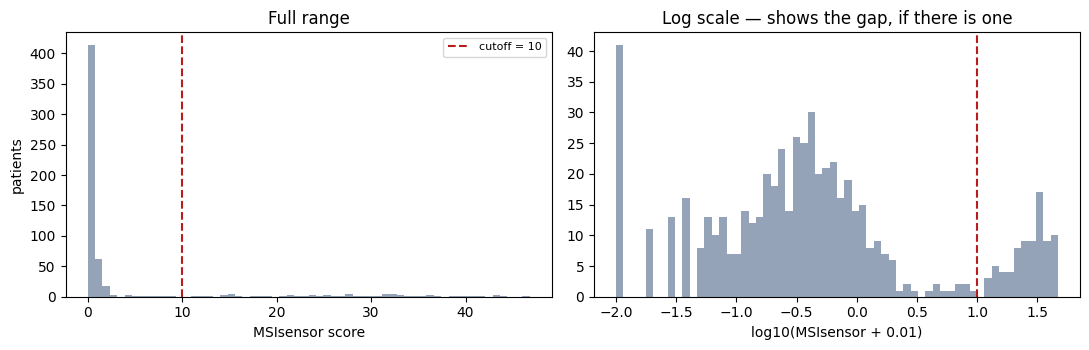

cases in the 3.5-10 grey zone : 10 (1.7%)
cases below 1.0                      : 439 (75.2%)
cases at or above cutoff (MSI-H)     : 78

A large low cluster + a small grey zone means the labels are unusually
clean relative to studies using equivocal IHC/PCR calls. Say so if true.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

s = labels["MSIsensor Score"].values

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(s, bins=60, color="#94a3b8")
axes[0].axvline(THRESHOLD, color="#b91c1c", ls="--", lw=1.5, label=f"cutoff = {THRESHOLD}")
axes[0].set_xlabel("MSIsensor score"); axes[0].set_ylabel("patients")
axes[0].set_title("Full range"); axes[0].legend(fontsize=8)

axes[1].hist(np.log10(s + 0.01), bins=60, color="#94a3b8")
axes[1].axvline(np.log10(THRESHOLD), color="#b91c1c", ls="--", lw=1.5)
axes[1].set_xlabel("log10(MSIsensor + 0.01)")
axes[1].set_title("Log scale — shows the gap, if there is one")
plt.tight_layout(); plt.show()

# How many cases sit in the ambiguous band below the cutoff?
grey = ((s >= 3.5) & (s < THRESHOLD)).sum()
print(f"cases in the 3.5-{THRESHOLD} grey zone : {grey} ({grey/len(s):.1%})")
print(f"cases below 1.0                      : {(s < 1.0).sum()} ({(s < 1.0).mean():.1%})")
print(f"cases at or above cutoff (MSI-H)     : {(s >= THRESHOLD).sum()}")
print("\nA large low cluster + a small grey zone means the labels are unusually")
print("clean relative to studies using equivocal IHC/PCR calls. Say so if true.")

## Section 3 — Build the slide → label manifest

Joins slide feature files (Section 1) to MSI labels (Section 2) via patient ID.
TCGA filenames encode the patient in their first three hyphen-separated segments:
`TCGA-AA-3506-01Z-00-DX1.h5` → `TCGA-AA-3506`.

The `-01Z` field is the **sample type** code (`01` = primary solid tumour,
`11` = solid tissue normal). Reading it off the barcode is more reliable than the
clinical table's `Sample Type` column.


In [ ]:
records = []
for fpath in coad_files:
    fname = os.path.basename(fpath)
    patient_id = "-".join(fname.split("-")[:3])
    records.append({"slide_id": fname, "patient_id": patient_id, "local_path": fpath})

manifest = pd.DataFrame(records)
# ... merge with labels as you already do
manifest = manifest.merge(
    labels[["PATIENT_ID", "label"]],
    left_on="patient_id", right_on="PATIENT_ID", how="inner"
)

print(f"Matched slides: {len(manifest)}")
manifest.head()

Matched slides: 419


,slide_id,patient_id,local_path,PATIENT_ID,label
0,TCGA-3L-AA1B-01Z-00-DX1.8923A151-A690-40B7-9E5...,TCGA-3L-AA1B,/content/TCGA_COAD_slides/TCGA-3L-AA1B-01Z-00-...,TCGA-3L-AA1B,0
1,TCGA-3L-AA1B-01Z-00-DX2.17CE3683-F4B1-4978-A28...,TCGA-3L-AA1B,/content/TCGA_COAD_slides/TCGA-3L-AA1B-01Z-00-...,TCGA-3L-AA1B,0
2,TCGA-4N-A93T-01Z-00-DX1.82E240B1-22C3-46E3-891...,TCGA-4N-A93T,/content/TCGA_COAD_slides/TCGA-4N-A93T-01Z-00-...,TCGA-4N-A93T,0
3,TCGA-4N-A93T-01Z-00-DX2.875E7F95-A6D4-4BEB-A33...,TCGA-4N-A93T,/content/TCGA_COAD_slides/TCGA-4N-A93T-01Z-00-...,TCGA-4N-A93T,0
4,TCGA-4T-AA8H-01Z-00-DX1.A46C759C-74A2-4724-B6B...,TCGA-4T-AA8H,/content/TCGA_COAD_slides/TCGA-4T-AA8H-01Z-00-...,TCGA-4T-AA8H,0


### Batch variables

Parsed off the TCGA barcode and **never used for training** — preserved so the
model can be interrogated later. Sample-type codes: `01` = primary solid
tumour, `06` = metastatic, `11` = solid tissue normal.

In [ ]:
manifest["site_id"]     = manifest["slide_id"].str.split("-").str[1]   # tissue source site
manifest["sample_type"] = manifest["slide_id"].str.split("-").str[3].str[:2]

print("Slides per sample type ('01' primary, '06' metastatic, '11' normal):")
print(manifest["sample_type"].value_counts().to_string())

n_nonprimary = int((manifest["sample_type"] != "01").sum())
if n_nonprimary:
    print(f"\nNOTE: {n_nonprimary} non-primary slide(s) present. Decide explicitly")
    print("whether to keep them, and say which you did. To drop:")
    print('  manifest = manifest[manifest["sample_type"] == "01"].reset_index(drop=True)')

print(f"\nDistinct tissue source sites: {manifest['site_id'].nunique()}")
print(f"Patients: {manifest['patient_id'].nunique()} | Slides: {len(manifest)}")
print(f"MSI-H slides: {manifest['label'].sum()} "
      f"({manifest['label'].mean():.1%} slide-level prevalence)")

Slides per sample type ('01' primary, '06' metastatic, '11' normal):
sample_type
01    418
06      1

NOTE: 1 non-primary slide(s) present. Decide explicitly
whether to keep them, and say which you did. To drop:
  manifest = manifest[manifest["sample_type"] == "01"].reset_index(drop=True)

Distinct tissue source sites: 24
Patients: 411 | Slides: 419
MSI-H slides: 67 (16.0% slide-level prevalence)


## Section 4 — MIL dataset

Bags have different tile counts and can't be stacked into a normal batch, hence
`batch_size=1`: one full slide per step. `view(-1, 1536)` in the training code
flattens the leading dimensions the loader adds.

In [ ]:
!pip install h5py -q
import h5py
from torch.utils.data import Dataset, DataLoader

class SlideDataset(Dataset):
    def __init__(self, manifest_df):
        self.slides = manifest_df.reset_index(drop=True)

    def __len__(self):
        return len(self.slides)

    def __getitem__(self, idx):
        row = self.slides.iloc[idx]
        with h5py.File(row["local_path"], "r") as f:
            data = f["features"][:]        # [N_tiles, 1536]
        features = torch.from_numpy(data).float()
        label = torch.tensor(row["label"], dtype=torch.long)
        return features, label

Sanity check: confirm a bag loads with the expected trailing dimension.

In [ ]:
_ds = SlideDataset(manifest)
_f, _l = _ds[0]
print("One bag:", tuple(_f.shape), "| label:", _l.item())
assert _f.shape[-1] == 1536, "Trailing dim must be 1536 (UNI2-h embedding size)"
del _ds, _f, _l

One bag: (1, 14853, 1536) | label: 0


## Section 5 — CLAM attention-MIL model

**This cell defines the class and the args only.**


In [ ]:
# Load CLAM_SB directly from the repo file and prepare the args namespace.

import os
import importlib.util
from types import SimpleNamespace

# Pin the CLAM implementation. On the first run leave CLAM_COMMIT = None, then
# paste the printed hash below and re-run so the notebook is reproducible: an
# unpinned clone can silently pick up a different CLAM implementation later.
CLAM_COMMIT = None      # <-- paste the hash printed below, then re-run

if not os.path.isdir("/content/CLAM"):
    !git clone -q https://github.com/mahmoodlab/CLAM /content/CLAM
if CLAM_COMMIT:
    !cd /content/CLAM && git checkout -q {CLAM_COMMIT}
print("CLAM commit in use:")
!cd /content/CLAM && git rev-parse HEAD

clam_model_file = "/content/CLAM/models/model_clam.py"
assert os.path.isfile(clam_model_file), f"model_clam.py not found at {clam_model_file}"

# Load the file as a module. (sys.path games and os.chdir do NOT help here —
# module search path is separate from working directory.)
spec = importlib.util.spec_from_file_location("clam_model_file", clam_model_file)
clam_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(clam_module)

CLAM_SB = clam_module.CLAM_SB

args = SimpleNamespace(
    gate=True,
    model_size="small",      # -> internal dims [1024, 512, 256]
    dropout=True,
    k_sample=8,
    n_classes=2,
    bag_loss="ce",
    inst_loss="svm",
    bag_dim=1536,
    task="task",
    feat_dropout=False,
    no_inst_cluster=False,
)

# model_size="small" makes CLAM expect 1024-dim input, but UNI2-h emits 1536.
# A Linear(1536, 1024) projection bridges the gap — built per-fold in Section 6.
print("CLAM_SB loaded. Model is NOT built here — Section 6 builds one per fold.")
print("Expected input dim:", 1024, "| UNI2-h emits:", 1536, "-> projection needed")

CLAM commit in use:
53e2409d4a8189c682c173382964a85f114f923c
CLAM_SB loaded. Model is NOT built here — Section 6 builds one per fold.
Expected input dim: 1024 | UNI2-h emits: 1536 -> projection needed


---

# Section 6 — 5-fold patient-level cross-validation

## Step 1 — Configuration

**Set `RUN_TAG` and the two switches below, then run the whole notebook.** Each
run saves its out-of-fold predictions to Drive under that tag, and the
comparison cell in Section 9 reads them all back and tabulates them side by
side. Do the runs in this order:

| `RUN_TAG` | change from default | why |
|---|---|---|
| `"main"` | none | clean headline + honest calibration |
| `"sitegrouped"` | `GROUP_COL = "site_id"` | **highest-value run** — how much was site signal? |
| `"permuted"` | `PERMUTE_LABELS = True` | makes the notebook self-contained |
| `"noproj"` | `TRAIN_PROJ = False` | cheapest interesting ablation |

Roughly 50 min each on a T4. If you only get two, do `main` and `sitegrouped`.

### What changed in this version, and why

Epochs are no longer a fixed constant chosen from test-set curves, and the
calibrator is no longer fitted on evaluation-fold labels. Both problems had the
same fix: **carve an inner split out of each training fold.**

Each fold now runs: train on the inner-fit slice → select the epoch on inner-val
*loss* → fit the calibrator on inner-val predictions → apply model and
calibrator to the untouched test fold. Nothing from the test fold reaches either
decision, so `prob_cal` is a genuine out-of-fold calibrated probability and the
operating point derived from it is reportable.

**Two honest costs of this design:**

- Training now uses 75% of each training fold instead of 100%. Expect AUROC to
  come in slightly below the old numbers. That is the correct number, not a
  regression.
- The calibrator fits on ~82 patients with ~13 positives. Workable for a
  two-parameter model, but noisy. This *relocates* the variance rather than
  removing it — the same constraint that makes MSIntuit use 30 calibration
  slides rather than 3.

**Epoch selection uses loss, not AUROC.** With ~13 positives in the inner-val
set, AUROC can take only 13 distinct values — far too coarse to select on. Loss
is smooth. `MAX_EPOCHS = 8` so you can see whether 3 was ever a sensible choice;
the per-epoch curve is saved to `epochs_{RUN_TAG}.csv`.

In [ ]:
import numpy as np
import pandas as pd
import torch
import copy
from torch import nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, brier_score_loss)
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- RUN SWITCHES
RUN_TAG        = "main"        # "main" | "sitegrouped" | "permuted" | "noproj"
GROUP_COL      = "patient_id"  # "site_id" for the site-grouped run
PERMUTE_LABELS = False         # True for the negative control
TRAIN_PROJ     = True          # False freezes the 1536->1024 projection
# ------------------------------------------------------------------------------

N_SPLITS   = 5
MAX_EPOCHS = 8         # upper bound; the epoch is SELECTED on inner-val loss
INNER_FRAC = 0.25      # of each training fold, held out for epoch + calibration
SEED       = 42
LR         = 1e-4

SAVE_DIR = "/content/drive/MyDrive/TCGA_COAD"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

for name in ["manifest", "SlideDataset", "CLAM_SB", "args", "device"]:
    assert name in globals(), f"{name} is missing — run the earlier sections first"

assert GROUP_COL in manifest.columns, f"{GROUP_COL} not in manifest"

print(f"RUN_TAG={RUN_TAG} | GROUP_COL={GROUP_COL} | "
      f"PERMUTE_LABELS={PERMUTE_LABELS} | TRAIN_PROJ={TRAIN_PROJ}")
print("device:", device)
if device == "cpu":
    print("WARNING: on CPU this will take hours. Runtime > Change runtime type > T4 GPU.")
print(f"{len(manifest)} slides, {manifest.patient_id.nunique()} patients, "
      f"{manifest.label.sum()} MSI-H slides")

# Guard against the most likely mistake across four runs: forgetting to change
# RUN_TAG, and silently overwriting a completed run's saved predictions.
_expected = {"main": ("patient_id", False, True), "sitegrouped": ("site_id", False, True),
             "permuted": ("patient_id", True, True), "noproj": ("patient_id", False, False)}
if RUN_TAG in _expected:
    e = _expected[RUN_TAG]
    if (GROUP_COL, PERMUTE_LABELS, TRAIN_PROJ) != e:
        print(f"\n*** WARNING: RUN_TAG='{RUN_TAG}' usually means "
              f"GROUP_COL={e[0]}, PERMUTE_LABELS={e[1]}, TRAIN_PROJ={e[2]}. "
              f"Check the switches before spending 50 GPU-minutes. ***")
if os.path.exists(f"{SAVE_DIR}/oof_{RUN_TAG}.csv"):
    print(f"\n*** NOTE: oof_{RUN_TAG}.csv already exists and will be OVERWRITTEN. ***")

RUN_TAG=main | GROUP_COL=patient_id | PERMUTE_LABELS=False | TRAIN_PROJ=True
device: cuda
419 slides, 411 patients, 67 MSI-H slides

*** NOTE: oof_main.csv already exists and will be OVERWRITTEN. ***


## Step 2 — Helper functions

`build_fresh_model()` is the important one. Everything with learnable state is
created here and it is called once per fold, so nothing carries over between
folds.

Three details worth noting:

- **Parameter budget.** `Linear(1536, 1024)` is ~1.57M parameters, roughly
  two-thirds of everything trained here, and it exists only to bridge UNI2-h's
  1536-dim output to CLAM's expected 1024. `TRAIN_PROJ = False` freezes it as a
  random projection.
- **`reduction='sum'`.** With `batch_size=1`, the default `'mean'` divides by
  the sample's own class weight and cancels the weighting exactly. This was a
  real bug, silently disabling class weights.
- **`train_one_epoch` replaces `train_fold`.** The loop now needs to evaluate
  after every epoch to select one, so epoch control moved out of the helper and
  into the loop.

In [ ]:
def set_seed(s):
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)


def build_fresh_model():
    """Every fold gets a brand-new model. Nothing here may live outside the loop."""
    clam = CLAM_SB(args).to(device)
    proj = nn.Linear(1536, 1024).to(device)

    params = list(clam.parameters())
    if TRAIN_PROJ:
        params += list(proj.parameters())
    else:
        for p in proj.parameters():
            p.requires_grad = False

    opt = torch.optim.Adam(params, lr=LR)
    return clam, proj, opt


def n_trainable(clam, proj):
    c = sum(p.numel() for p in clam.parameters() if p.requires_grad)
    p_ = sum(p.numel() for p in proj.parameters() if p.requires_grad)
    return c, p_


def make_criterion(train_df):
    """Class weights depend on the training set, which changes every fold."""
    n_mss  = int((train_df["label"] == 0).sum())
    n_msih = int((train_df["label"] == 1).sum())
    w = torch.tensor([1.0 / n_mss, 1.0 / n_msih], dtype=torch.float)
    w = w / w.mean()                       # keep gradient scale sane
    # reduction='sum': with batch_size=1, 'mean' divides by the sample's own
    # weight and cancels the weighting exactly.
    return nn.CrossEntropyLoss(weight=w.to(device), reduction="sum"), w.tolist()


def train_one_epoch(clam, proj, opt, criterion, loader):
    """One pass over the inner-fit set. Returns mean training loss."""
    clam.train()
    proj.train()
    total = 0.0
    for features, label in loader:
        features = features.view(-1, 1536).to(device)
        label = label.view(-1).to(device)
        opt.zero_grad()
        logits, _, _, _, inst = clam(proj(features), label=label, instance_eval=True)
        loss = 0.7 * criterion(logits, label) + 0.3 * inst["instance_loss"]
        loss.backward()
        opt.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def inner_val_loss(clam, proj, criterion, loader):
    """Bag loss on the inner-val set. Selection signal for the epoch count.

    Loss, not AUROC: with ~13 positives the inner-val AUROC can take only 13
    distinct values, which is far too coarse to select on. Loss is smooth.
    """
    clam.eval()
    proj.eval()
    total = 0.0
    for features, label in loader:
        features = features.view(-1, 1536).to(device)
        label = label.view(-1).to(device)
        logits, _, _, _, _ = clam(proj(features))
        total += criterion(logits, label).item()
    return total / len(loader)


@torch.no_grad()
def predict(clam, proj, loader):
    clam.eval()
    proj.eval()          # proj is a separate module; clam.eval() does not cover it
    out = []
    for features, _ in loader:
        features = features.view(-1, 1536).to(device)
        logits, _, _, _, _ = clam(proj(features))
        out.append(torch.softmax(logits, dim=1)[0, 1].item())
    return out


def logit(p, eps=1e-6):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    return np.log(p / (1 - p))

## Step 3 — The fold loop, with a nested inner split

`StratifiedGroupKFold` does two jobs at once, and you need both:

- `groups=GROUP_COL` — every member of a group stays on the same side. With
  `patient_id` that is the patient-level guarantee. With `site_id` it becomes
  the site-grouped run, which is the honest internal proxy for external
  validation.
- `y=label` — every fold gets roughly the same MSI-H prevalence.

Plain `GroupKFold` gives the first and not the second — a common quiet mistake.

**Inside each training fold**, patients are split again (stratified, grouped by
patient) into an inner-fit slice and an inner-val slice. The inner-val slice does
two jobs and never touches the test fold:

1. **Selects the epoch**, by loss.
2. **Fits the Platt calibrator**, which is then applied to the test fold.

Note what this buys. The old version fitted the calibrator on the evaluation
fold's own labels. Cross-fitting made each *individual* prediction honest, but
AUROC averages over **pairs** — patient *i* scored by a calibrator trained on
*j*'s label and vice versa — so the pairwise comparison stayed contaminated.
Fitting on inner-val removes that entirely.

**On site-grouped folds:** expect messier prevalence. Site AA is ~34% of all
slides and two sites have zero MSI-H, so stratifying by label while grouping by
site is only approximate. The fold table is printed so you can see it; don't be
alarmed, just report it.

The `del` + `empty_cache()` at the end matters: five CLAM models plus bags of up
to 16k x 1536 floats will exhaust a T4 otherwise.

In [ ]:
# ---- Run mode: real labels, or permuted-label negative control ----------------
# ONE switch. ONE shuffle. Set True for the control run, False for the real run.
#
# Permutation is PATIENT-LEVEL: each patient's label is shuffled as a unit, so a
# multi-slide patient never ends up with inconsistent labels. (Row-level shuffling
# would leak patient identity into the labels and inflate the control.)

PERMUTE_LABELS = False   # True = negative control (expect ~0.5); False = real run

run_manifest = manifest.copy()
if PERMUTE_LABELS:
    _pat_labels = manifest.groupby("patient_id")["label"].first()
    _shuffled = pd.Series(
        np.random.default_rng(0).permutation(_pat_labels.values),
        index=_pat_labels.index,
    )
    run_manifest["label"] = run_manifest["patient_id"].map(_shuffled)
    print(">>> PERMUTED-LABEL CONTROL. Expect pooled AUROC ~0.5. <<<")
    print(">>> Per-fold AUROCs should scatter on BOTH sides of 0.5.  <<<")
    print(">>> If this scores near your real ~0.90, the control is   <<<")
    print(">>> not wired through OR the pipeline leaks. Check which.  <<<")
    # Proof the shuffle actually changed something, printed so you can SEE it:
    _agree = (run_manifest["label"].values == manifest["label"].values).mean()
    print(f"    (permuted labels match originals on {_agree:.1%} of slides "
          f"-- should be roughly the MSI-H prevalence, not 100%)")
else:
    print("REAL LABELS -- this is a scored run.")


REAL LABELS -- this is a scored run.


In [ ]:
skf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
active_manifest = run_manifest          # set by the mode cell above

if PERMUTE_LABELS:
    _match = (active_manifest["label"].values == manifest["label"].values).mean()
    assert _match < 0.90, (
        f"Permuted control not wired through: active labels match real labels on "
        f"{_match:.0%} of slides. The loop is reading real labels."
    )
    print(f"[control check] active labels differ from real on "
          f"{1-_match:.0%} of slides -- permutation IS reaching the loop.\n")

splits = list(skf.split(active_manifest, active_manifest["label"],
                        groups=active_manifest[GROUP_COL]))

oof_frames, epoch_log = [], []

for fold, (tr_idx, te_idx) in enumerate(splits):
    print(f"\n===== FOLD {fold+1}/{N_SPLITS} =====")
    set_seed(SEED + fold)

    tr_all = active_manifest.iloc[tr_idx].reset_index(drop=True)
    te_df  = active_manifest.iloc[te_idx].reset_index(drop=True).copy()

    # --- Inner split of the TRAINING fold, grouped by patient, stratified ------
    tr_pts = tr_all.groupby("patient_id")["label"].max().reset_index()
    fit_p, cal_p = train_test_split(
        tr_pts.patient_id, test_size=INNER_FRAC,
        stratify=tr_pts.label, random_state=SEED + fold)
    fit_df = tr_all[tr_all.patient_id.isin(fit_p)].reset_index(drop=True)
    cal_df = tr_all[tr_all.patient_id.isin(cal_p)].reset_index(drop=True)

    # Three-way disjointness. Any overlap invalidates the whole run.
    assert not (set(fit_df.patient_id) & set(cal_df.patient_id)), "LEAK: fit/inner-val"
    assert not (set(tr_all.patient_id) & set(te_df.patient_id)),  "LEAK: train/test"
    assert cal_df.label.nunique() == 2, (
        f"fold {fold}: inner-val has one class only ({int(cal_df.label.sum())} MSI-H) "
        "— cannot fit a calibrator. Raise INNER_FRAC.")

    print(f"  inner-fit: {len(fit_df):3d} sl / {fit_df.patient_id.nunique():3d} pts "
          f"({fit_df.label.sum()} MSI-H)")
    print(f"  inner-val: {len(cal_df):3d} sl / {cal_df.patient_id.nunique():3d} pts "
          f"({cal_df.label.sum()} MSI-H)")
    print(f"  test     : {len(te_df):3d} sl / {te_df.patient_id.nunique():3d} pts "
          f"({te_df.label.sum()} MSI-H)")
    if GROUP_COL == "site_id":
        print(f"  test sites: {sorted(te_df.site_id.unique())}")

    fit_loader = DataLoader(SlideDataset(fit_df), batch_size=1, shuffle=True)
    cal_loader = DataLoader(SlideDataset(cal_df), batch_size=1, shuffle=False)
    te_loader  = DataLoader(SlideDataset(te_df),  batch_size=1, shuffle=False)

    clam, proj, opt = build_fresh_model()
    criterion, wts = make_criterion(fit_df)
    if fold == 0:
        n_c, n_p = n_trainable(clam, proj)
        print(f"  trainable params: CLAM {n_c:,} + projection {n_p:,} = {n_c+n_p:,}"
              + (f"  (projection is {n_p/(n_c+n_p):.0%})" if n_p else "  (projection FROZEN)"))
    print(f"  class weights [MSS, MSI-H]: {[round(x,3) for x in wts]}")

    # --- Epoch selection on inner-val LOSS ------------------------------------
    best_loss, best_ep, best_state = np.inf, 0, None
    for ep in range(1, MAX_EPOCHS + 1):
        tl = train_one_epoch(clam, proj, opt, criterion, fit_loader)
        vl = inner_val_loss(clam, proj, criterion, cal_loader)
        epoch_log.append({"run": RUN_TAG, "fold": fold, "epoch": ep,
                          "train_loss": tl, "inner_val_loss": vl})
        flag = ""
        if vl < best_loss:
            best_loss, best_ep = vl, ep
            best_state = {"clam": copy.deepcopy(clam.state_dict()),
                          "proj": copy.deepcopy(proj.state_dict())}
            flag = "  <- best"
        print(f"    epoch {ep}/{MAX_EPOCHS}  train {tl:.4f}  inner-val {vl:.4f}{flag}")

    clam.load_state_dict(best_state["clam"])
    proj.load_state_dict(best_state["proj"])
    print(f"  selected epoch {best_ep} (inner-val loss {best_loss:.4f})")

    # --- Calibrator fitted on inner-val, applied to the test fold -------------
    cal_probs = predict(clam, proj, cal_loader)
    platt = LogisticRegression().fit(logit(cal_probs).reshape(-1, 1),
                                     cal_df.label.values)
    slope = float(platt.coef_[0, 0])

    te_df["prob"] = predict(clam, proj, te_loader)
    if slope > 0:
        te_df["prob_cal"] = platt.predict_proba(
            logit(te_df.prob.values).reshape(-1, 1))[:, 1]
    else:
        # A NEGATIVE slope means the calibrator learned to INVERT the ranking.
        # On ~13 inner-val positives that is a real possibility, not a
        # hypothetical: the fit is noise-dominated. Applying it would flip this
        # fold's ordering and silently wreck the pooled AUROC. Fall back to the
        # uncalibrated score and record it rather than shipping an inversion.
        te_df["prob_cal"] = te_df["prob"]
        print(f"  *** WARNING fold {fold}: Platt slope {slope:+.3f} <= 0 on "
              f"{cal_df.label.sum()} inner-val positives. Calibration would "
              f"invert the ranking; falling back to raw scores for this fold. "
              f"Report this. ***")
    te_df["platt_slope"] = slope
    te_df["platt_used"] = slope > 0
    te_df["fold"] = fold
    te_df["sel_epoch"] = best_ep

    print(f"  fold AUROC (slide, raw): {roc_auc_score(te_df.label, te_df.prob):.4f}"
          f" | (slide, calibrated): {roc_auc_score(te_df.label, te_df.prob_cal):.4f}")

    keep = ["patient_id", "slide_id", "label", "prob", "prob_cal", "fold", "sel_epoch"]
    if "site_id" in te_df.columns:
        keep.append("site_id")
    oof_frames.append(te_df[keep])

    del clam, proj, opt, best_state
    if device == "cuda":
        torch.cuda.empty_cache()

oof = pd.concat(oof_frames, ignore_index=True)
assert len(oof) == len(active_manifest)
assert oof.patient_id.nunique() == active_manifest.patient_id.nunique()

# Save immediately — Colab will disconnect eventually and a finished run is
# 50 GPU-minutes you do not want to repeat.
oof.to_csv(f"{SAVE_DIR}/oof_{RUN_TAG}.csv", index=False)
pd.DataFrame(epoch_log).to_csv(f"{SAVE_DIR}/epochs_{RUN_TAG}.csv", index=False)
print(f"\nOut-of-fold predictions for {len(oof)} slides.")
print(f"Selected epochs per fold: {oof.groupby('fold').sel_epoch.first().tolist()}")
print(f"Saved -> {SAVE_DIR}/oof_{RUN_TAG}.csv")


===== FOLD 1/5 =====
  inner-fit: 251 sl / 246 pts (41 MSI-H)
  inner-val:  86 sl /  83 pts (13 MSI-H)
  test     :  82 sl /  82 pts (13 MSI-H)
  trainable params: CLAM 790,791 + projection 1,573,888 = 2,364,679  (projection is 67%)
  class weights [MSS, MSI-H]: [0.327, 1.673]
    epoch 1/8  train 0.2664  inner-val 0.2525  <- best
    epoch 2/8  train 0.1408  inner-val 0.1951  <- best
    epoch 3/8  train 0.0993  inner-val 0.3124
    epoch 4/8  train 0.0656  inner-val 0.2688
    epoch 5/8  train 0.0500  inner-val 0.3309
    epoch 6/8  train 0.0576  inner-val 0.4118
    epoch 7/8  train 0.0362  inner-val 0.4052
    epoch 8/8  train 0.0180  inner-val 0.7263
  selected epoch 2 (inner-val loss 0.1951)
  fold AUROC (slide, raw): 0.9320 | (slide, calibrated): 0.9320

===== FOLD 2/5 =====
  inner-fit: 250 sl / 246 pts (41 MSI-H)
  inner-val:  84 sl /  83 pts (13 MSI-H)
  test     :  85 sl /  82 pts (13 MSI-H)
  class weights [MSS, MSI-H]: [0.328, 1.672]
    epoch 1/8  train 0.2705  inner-val

## Step 4 — Pool to patient level

A patient with three slides currently contributes three predictions. Collapse
to one prediction per patient (mean probability across their slides):

- The claim is about *patients*, not glass. Clinically a person is tested once.
- The bootstrap below resamples patients. If patients are represented unequally
  the resample is malformed.

`mean` is the aggregation choice; `max` is also defensible for a screening tool
(any suspicious slide flags the patient) and is reported as a sensitivity
analysis below.

**Everything downstream of this cell is patient-level.** Mixing slide-level and
patient-level metrics in one narrative is a reporting error.

In [ ]:
# Recover per-fold Platt slopes from predictions already in `oof`.
# Platt is prob_cal = sigmoid(a*logit(prob) + b), so logit(prob_cal) is EXACTLY
# linear in logit(prob) within a fold. Regressing one on the other recovers `a`.

if "platt_slope" not in oof.columns:
    slopes, used = {}, {}
    for f, d in oof.groupby("fold"):
        if np.allclose(d.prob.values, d.prob_cal.values):
            slopes[f], used[f] = 1.0, False      # fold fell back to raw scores
            continue
        a, b = np.polyfit(logit(d.prob.values), logit(d.prob_cal.values), 1)
        # Confirm the linear form actually holds — if it doesn't, prob_cal
        # wasn't produced by a per-fold Platt map and something is wrong.
        resid = np.max(np.abs(logit(d.prob_cal.values)
                              - (a * logit(d.prob.values) + b)))
        assert resid < 1e-4, (
            f"fold {f}: logit(prob_cal) is not linear in logit(prob) "
            f"(max residual {resid:.2e}). prob_cal did not come from a per-fold "
            "Platt fit — do not trust the recovered slope.")
        slopes[f], used[f] = float(a), float(a) > 0

    oof["platt_slope"] = oof.fold.map(slopes)
    oof["platt_used"]  = oof.fold.map(used)

    print("Recovered per-fold Platt slopes (exact, not estimated):")
    for f in sorted(slopes):
        n_pos = int(oof.loc[oof.fold == f, "label"].sum())
        flag = "" if used[f] else "   <- NOT USED (fallback to raw)"
        print(f"  fold {f}: slope {slopes[f]:+.3f}   ({n_pos} MSI-H slides){flag}")

    if not all(used.values()):
        bad = [f for f in used if not used[f]]
        print(f"\n*** Folds {bad} used raw scores: the calibrator fitted a "
              "non-positive slope on a small inner-val set. Report this. ***")
else:
    print("platt_slope already present — nothing to recover.")

Recovered per-fold Platt slopes (exact, not estimated):
  fold 0: slope +1.154   (13 MSI-H slides)
  fold 1: slope +0.717   (13 MSI-H slides)
  fold 2: slope +1.251   (19 MSI-H slides)
  fold 3: slope +0.685   (10 MSI-H slides)
  fold 4: slope +1.018   (12 MSI-H slides)


In [ ]:
# Guard: a patient must live in exactly one fold, or "first" is silently lossy.
_folds_per_patient = oof.groupby("patient_id")["fold"].nunique()
assert (_folds_per_patient == 1).all(), (
    f"{(_folds_per_patient > 1).sum()} patients span multiple folds — "
    "grouping is broken upstream."
)

pt = (oof.groupby("patient_id")
         .agg(label=("label", "first"),
              prob=("prob", "mean"),
              cal=("prob_cal", "mean"),          # honest out-of-fold calibrated
              prob_max=("prob", "max"),
              fold=("fold", "first"),
              platt_slope=("platt_slope", "first"),
              platt_used=("platt_used", "first"),
              n_slides=("prob", "size"))
         .reset_index())

n_pos = int(pt.label.sum())
n_neg = int((pt.label == 0).sum())
pooled_auc = roc_auc_score(pt.label, pt.prob)

print(f"Patients: {len(pt)}  |  MSI-H: {n_pos}  MSS: {n_neg}  "
      f"|  prevalence: {n_pos/len(pt):.1%}")
print(f"Patients with >1 slide: {(pt.n_slides > 1).sum()}")
print(f"\nPooled patient-level AUROC, raw scores        : {pooled_auc:.4f}")
print(f"Pooled patient-level AUROC, calibrated       : {roc_auc_score(pt.label, pt.cal):.4f}")
print(f"Pooled patient-level AUROC, max aggregation  : "
      f"{roc_auc_score(pt.label, pt.prob_max):.4f}")
print()
print("`cal` is now a genuine out-of-fold calibrated probability: the calibrator")
print("was fitted on inner-val patients inside the training fold, so no test-fold")
print("label reached it. Operating points from `cal` are reportable.")

Patients: 411  |  MSI-H: 66  MSS: 345  |  prevalence: 16.1%
Patients with >1 slide: 7

Pooled patient-level AUROC, raw scores        : 0.8761
Pooled patient-level AUROC, calibrated       : 0.8754
Pooled patient-level AUROC, max aggregation  : 0.8761

`cal` is now a genuine out-of-fold calibrated probability: the calibrator
was fitted on inner-val patients inside the training fold, so no test-fold
label reached it. Operating points from `cal` are reportable.


## Step 5 — Confidence intervals, attached to the right estimand

Two different numbers need two different intervals, and mixing them is a real
reporting error:

- **Macro AUROC** (mean of the five per-fold AUROCs) is the headline. Each fold
  AUROC uses only within-fold ordering, so it is blind to cross-fold scale and
  carries no whole-cohort information.
- **Pooled AUROC** ranks every patient against every other, including patients
  scored by different models.

The macro interval below is a **cluster bootstrap**: patients are resampled
*within* each fold, the five fold AUROCs are recomputed, and their mean is taken
— 2,000 times. This is better than a t-interval on the five fold estimates,
which would capture between-fold variation while ignoring that each fold AUROC
is itself estimated from ~82 patients.

Both intervals remain anticonservative: the five folds share training data, so
they are not independent replicates.

**Report the macro number with its fold range and SD, not as a bare decimal.**
A single polished figure implies a precision that five folds of ~82 patients
cannot support.

In [ ]:
def boot_auc(y, p, n_boot=2000, seed=0):
    """Bootstrap CI for a POOLED AUROC. Resamples patients."""
    rng = np.random.default_rng(seed)
    n = len(y)
    out, skipped = [], 0
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2:
            skipped += 1
            continue
        out.append(roc_auc_score(y[idx], p[idx]))
    lo, hi = np.percentile(out, [2.5, 97.5])
    return lo, hi, skipped


def boot_macro(df, score_col="prob", n_boot=2000, seed=0):
    """Cluster bootstrap for MACRO AUROC: resample patients WITHIN each fold,
    recompute the five fold AUROCs, take their mean."""
    rng = np.random.default_rng(seed)
    folds = [(d.label.values, d[score_col].values) for _, d in df.groupby("fold")]
    out, skipped = [], 0
    for _ in range(n_boot):
        aucs = []
        for y_, p_ in folds:
            idx = rng.integers(0, len(y_), len(y_))
            if len(np.unique(y_[idx])) < 2:
                break
            aucs.append(roc_auc_score(y_[idx], p_[idx]))
        if len(aucs) == len(folds):
            out.append(np.mean(aucs))
        else:
            skipped += 1
    lo, hi = np.percentile(out, [2.5, 97.5])
    return lo, hi, skipped


per_fold = pt.groupby("fold").apply(
    lambda d: roc_auc_score(d.label, d.prob), include_groups=False)
macro = per_fold.mean()

lo_m, hi_m, sk_m = boot_macro(pt, "prob")
lo_p, hi_p, sk_p = boot_auc(pt.label.values, pt.prob.values)

print("HEADLINE (macro = mean of five per-fold patient-level AUROCs)")
print(f"  {macro:.3f}  95% CI [{lo_m:.3f}, {hi_m:.3f}]   (cluster bootstrap)")
print(f"  per-fold : {[round(v, 3) for v in per_fold.tolist()]}")
print(f"  range {per_fold.min():.3f}-{per_fold.max():.3f}   SD {per_fold.std(ddof=1):.3f}")
print(f"  degenerate resamples skipped: {sk_m}/2000")
print()
print("SECONDARY (pooled: every patient ranked against every other, across folds)")
print(f"  {roc_auc_score(pt.label, pt.prob):.3f}  95% CI [{lo_p:.3f}, {hi_p:.3f}]")
print(f"  degenerate resamples skipped: {sk_p}/2000")
print()
print("Quote the macro line, with its range and SD. The pooled interval belongs")
print("to the pooled number and must not be attached to the macro headline.")
print("All SDs in this notebook use ddof=1 (sample SD).")

HEADLINE (macro = mean of five per-fold patient-level AUROCs)
  0.895  95% CI [0.850, 0.934]   (cluster bootstrap)
  per-fold : [0.932, 0.943, 0.865, 0.957, 0.776]
  range 0.776-0.957   SD 0.075
  degenerate resamples skipped: 0/2000

SECONDARY (pooled: every patient ranked against every other, across folds)
  0.876  95% CI [0.824, 0.923]
  degenerate resamples skipped: 0/2000

Quote the macro line, with its range and SD. The pooled interval belongs
to the pooled number and must not be attached to the macro headline.
All SDs in this notebook use ddof=1 (sample SD).


---

# Section 7 — The scale diagnostic

The pooled AUROC is somewhat lower than the mean of the per-fold AUROCs. That
gap is worth understanding, though **how large it is depends heavily on how the
models were trained** — see the note at the end of this section.

**AUROC is invariant under any strictly monotonic transformation of the
scores.** It depends only on ordering. Two consequences:

1. Computed *within* a fold, every pair compared comes from the same model, so
   the absolute score scale is irrelevant. Per-fold AUROC is blind to scale.
2. Computed on *pooled* out-of-fold predictions, a positive scored by fold 3's
   model is compared against a negative scored by fold 0's. If the five models
   put their scores on different scales, those cross-fold pairs get ordered by
   *which model scored them* rather than by biology.

So the macro/micro gap is **consistent with** cross-fold scale drift, and the
rank-normalisation check below supports that reading. But it is not a pure
measurement of scale drift, and the honest phrasing is that **score
harmonisation accounts for part of the gap**. At least one other mechanism
contributes: fold prevalence varies here, and pooling folds with different base
rates can shift the micro AUROC independently of any scale effect.

The 2x2 below holds aggregation level constant so the comparison changes one
variable at a time.

In [ ]:
rows = []
for f, d in pt.groupby("fold"):
    npos = int(d.label.sum())
    base = d.label.mean()
    bs   = brier_score_loss(d.label, d.prob)
    rows.append({
        "fold": f,
        "n_patients": len(d),
        "n_MSI_H": npos,
        "prevalence": base,
        "AUROC": roc_auc_score(d.label, d.prob) if 0 < npos < len(d) else np.nan,
        "Brier": bs,
        "BSS": 1 - bs / (base * (1 - base)),      # reference = THIS fold's base rate
        "mean_prob_MSS":  d.loc[d.label == 0, "prob"].mean(),
        "mean_prob_MSIH": d.loc[d.label == 1, "prob"].mean(),
    })

fold_tbl = pd.DataFrame(rows)
fold_tbl["separation"] = fold_tbl.mean_prob_MSIH - fold_tbl.mean_prob_MSS
print("Per-fold, PATIENT level. BSS reference is each fold's own base rate.\n")
print(fold_tbl.round(3).to_string(index=False))

print(f"\nWithin-fold separation range : "
      f"{fold_tbl.separation.min():.3f} - {fold_tbl.separation.max():.3f}")
print(f"Absolute MSS score level varies by "
      f"{fold_tbl.mean_prob_MSS.max()/fold_tbl.mean_prob_MSS.min():.0f}x across folds")
print(f"Fold prevalence range        : "
      f"{fold_tbl.prevalence.min():.1%} - {fold_tbl.prevalence.max():.1%}")
print("\nNote: BSS is not comparable across folds with different prevalence —")
print("the reference Brier is p(1-p), which shrinks as p moves away from 0.5.")

Per-fold, PATIENT level. BSS reference is each fold's own base rate.

 fold  n_patients  n_MSI_H  prevalence  AUROC  Brier    BSS  mean_prob_MSS  mean_prob_MSIH  separation
    0          82       13       0.159  0.932  0.117  0.127          0.247           0.777       0.530
    1          82       13       0.159  0.943  0.149 -0.118          0.295           0.863       0.568
    2          83       19       0.229  0.865  0.154  0.125          0.326           0.711       0.386
    3          82       10       0.122  0.957  0.128 -0.197          0.221           0.936       0.716
    4          82       11       0.134  0.776  0.117 -0.011          0.146           0.462       0.317

Within-fold separation range : 0.317 - 0.716
Absolute MSS score level varies by 2x across folds
Fold prevalence range        : 12.2% - 22.9%

Note: BSS is not comparable across folds with different prevalence —
the reference Brier is p(1-p), which shrinks as p moves away from 0.5.


In [ ]:
def macro_micro(df, score_col="prob"):
    """Mean-of-per-fold (macro) and pooled (micro) AUROC at one aggregation level."""
    per_fold = df.groupby("fold").apply(
        lambda d: roc_auc_score(d.label, d[score_col]), include_groups=False)
    return per_fold.mean(), roc_auc_score(df.label, df[score_col]), per_fold

slide_macro, slide_micro, _ = macro_micro(oof)
pt_macro,    pt_micro,    _ = macro_micro(pt)

print(f"{'':14} {'macro (mean per-fold)':>22} {'micro (pooled)':>16} {'gap':>8}")
print(f"{'slide-level':14} {slide_macro:>22.3f} {slide_micro:>16.3f} {slide_macro-slide_micro:>8.3f}")
print(f"{'patient-level':14} {pt_macro:>22.3f} {pt_micro:>16.3f} {pt_macro-pt_micro:>8.3f}")
print()
print("Down a column = effect of aggregation level (should be near zero).")
print("Across a row  = effect of pooling predictions from five separate models.")
print("               Consistent with score-scale drift; see the rank-normalisation")
print("               check below. Differing fold prevalence also contributes.")

                macro (mean per-fold)   micro (pooled)      gap
slide-level                     0.891            0.866    0.024
patient-level                   0.895            0.876    0.019

Down a column = effect of aggregation level (should be near zero).
Across a row  = effect of pooling predictions from five separate models.
               Consistent with score-scale drift; see the rank-normalisation
               check below. Differing fold prevalence also contributes.


### Confirming the mechanism

If the gap really is scale, then removing the scale differences without
touching any model's internal ordering should recover it. Rank-normalising
within fold does exactly that: each patient's raw probability becomes a
percentile within their own fold.

The target to match is the macro AUROC, which never compares across folds at
all. If rank-normalised pooled ≈ macro, the gap was scale, not lost
discrimination.

In [ ]:
oof["prob_rank"] = oof.groupby("fold")["prob"].rank(pct=True)

pt_r = (oof.groupby("patient_id")
           .agg(label=("label", "first"),
                score=("prob_rank", "mean"),
                fold=("fold", "first"))
           .reset_index())

auc_r = roc_auc_score(pt_r.label, pt_r.score)
lo_r, hi_r, _ = boot_auc(pt_r.label.values, pt_r.score.values)

print(f"patient-level pooled, raw scores  : {pt_micro:.3f}")
print(f"patient-level pooled, rank-normed : {auc_r:.3f}  95% CI [{lo_r:.3f}, {hi_r:.3f}]")
print(f"patient-level macro (scale-blind) : {pt_macro:.3f}")
recovered = (auc_r - pt_micro) / (pt_macro - pt_micro)
print(f"\nfraction of the gap recovered by rank-normalisation: {recovered:.0%}")
print("\nCaveat: computing a percentile requires the whole cohort's scores.")
print("Real patients arrive one at a time, so this is an internal estimate of")
print("achievable performance, NOT a deployable rule.")
print()
print("HOW BIG THIS GAP IS DEPENDS ON TRAINING. An earlier version of this")
print("notebook trained every fold for a fixed 3 epochs and saw a gap of ~0.075,")
print("with the mean MSS score varying >10x across folds. Selecting each fold's")
print("epoch on inner-val loss shrank it substantially: folds that would have run")
print("well past their optimum emit far more extreme probabilities, and it was")
print("that difference in how far each fold overfitted -- not anything intrinsic")
print("to cross-validation -- that produced most of the drift. Compare the")
print("selected epochs printed in Section 6 against a fixed 3.")

patient-level pooled, raw scores  : 0.876
patient-level pooled, rank-normed : 0.890  95% CI [0.841, 0.931]
patient-level macro (scale-blind) : 0.895

fraction of the gap recovered by rank-normalisation: 73%

Caveat: computing a percentile requires the whole cohort's scores.
Real patients arrive one at a time, so this is an internal estimate of
achievable performance, NOT a deployable rule.

HOW BIG THIS GAP IS DEPENDS ON TRAINING. An earlier version of this
notebook trained every fold for a fixed 3 epochs and saw a gap of ~0.075,
with the mean MSS score varying >10x across folds. Selecting each fold's
epoch on inner-val loss shrank it substantially: folds that would have run
well past their optimum emit far more extreme probabilities, and it was
that difference in how far each fold overfitted -- not anything intrinsic
to cross-validation -- that produced most of the drift. Compare the
selected epochs printed in Section 6 against a fixed 3.


---

## Section 7b — Mean-pooling baseline

The open question this notebook could not answer until now: **does attention
add anything over averaging?**

CLAM learns which tiles matter. The null hypothesis is that it doesn't need to —
that averaging all of a slide's tile embeddings into one 1536-d vector and
fitting logistic regression gets you the same place. If that's true, 2.36M
trainable parameters are buying nothing and the honest description of this
project is "mean-pooled UNI2-h slide representations are already highly
predictive of MSI status with a linear classifier." Note the precision: the
tiles are averaged BEFORE the linear fit, so this says nothing about whether
individual tile embeddings are linearly separable.

Same folds, same patients, same aggregation, no GPU. The only difference is what
replaces the attention mechanism.

In [ ]:
import h5py
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# One mean-pooled vector per slide. ~419 file reads; a few minutes, no GPU.
X = np.zeros((len(manifest), 1536), dtype=np.float32)
for i, p in enumerate(manifest["local_path"].values):
    with h5py.File(p, "r") as f:
        # reshape(-1, 1536) first — same normalisation the training path does
        # with .view(-1, 1536). These files carry a leading singleton dim.
        tiles = f["features"][:].reshape(-1, 1536)
    X[i] = tiles.mean(axis=0)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(manifest)} slides pooled")

assert X.shape == (len(manifest), 1536)
assert np.isfinite(X).all(), "non-finite values in mean-pooled features"
print(f"mean-pooled feature matrix: {X.shape}")

# Labels come from active_manifest, NOT manifest: these differ on the permuted
# run, and reading real labels there would make the negative control score ~0.85
# and look exactly like a pipeline leak.
y = active_manifest["label"].values

# X was built in manifest row order; `splits` indexes active_manifest. Same
# order today (run_manifest = manifest.copy()), but a mismatch would silently
# pair features with the wrong labels and still produce a plausible AUROC.
assert len(X) == len(active_manifest)
assert (active_manifest["slide_id"].values == manifest["slide_id"].values).all(), \
    "active_manifest row order differs from manifest — X and y are misaligned"

# Reuse `splits` from Section 6 so the comparison is fold-for-fold identical.
frames = []
for fold, (tr_idx, te_idx) in enumerate(splits):
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=5000, class_weight="balanced"))
    clf.fit(X[tr_idx], y[tr_idx])
    d = active_manifest.iloc[te_idx][["patient_id", "label"]].copy()
    d["prob"] = clf.predict_proba(X[te_idx])[:, 1]
    d["fold"] = fold
    frames.append(d)

oof_b = pd.concat(frames, ignore_index=True)
pt_b = (oof_b.groupby("patient_id")
             .agg(label=("label", "first"), prob=("prob", "mean"), fold=("fold", "first"))
             .reset_index())

b_macro, b_micro, b_pf = macro_micro(pt_b)

print(f"\n{'':28} {'macro':>8} {'micro (pooled)':>16}")
print(f"{'mean-pool + logistic reg':28} {b_macro:>8.3f} {b_micro:>16.3f}")
print(f"{'CLAM attention-MIL':28} {pt_macro:>8.3f} {pt_micro:>16.3f}")
print(f"{'difference (CLAM - baseline)':28} {pt_macro-b_macro:>+8.3f} {pt_micro-b_micro:>+16.3f}")
print(f"\nbaseline per-fold AUROC: {[round(v,3) for v in b_pf.tolist()]}")

lo_b, hi_b, _ = boot_auc(pt_b.label.values, pt_b.prob.values)
print(f"baseline pooled AUROC 95% CI: [{lo_b:.3f}, {hi_b:.3f}]")

# Is the CLAM-vs-baseline gap larger than the fold-to-fold noise?
# ddof=1 (sample SD) everywhere in this notebook. numpy defaults to ddof=0 and
# pandas to ddof=1; mixing them prints two different SDs for the same quantity.
clam_pf = pt.groupby("fold").apply(
    lambda d: roc_auc_score(d.label, d.prob), include_groups=False)
spread = max(b_pf.std(ddof=1), clam_pf.std(ddof=1))
delta = pt_macro - b_macro
print(f"\ndelta (macro) {delta:+.3f}  vs  larger fold-to-fold SD {spread:.3f}")
if abs(delta) < spread:
    print("Delta is SMALLER than the fold-to-fold spread. At this sample size you")
    print("cannot distinguish attention-MIL from mean pooling. The finding:")
    print("MEAN-POOLED UNI2-h slide representations are already highly predictive")
    print("of MSI status with a linear classifier, and the 2.36M-parameter")
    print("attention head is not demonstrably earning its complexity.")
    print()
    print("Note the precise claim: the tiles are averaged BEFORE the linear fit, so")
    print("this says nothing about whether individual tile embeddings are linearly")
    print("separable. Do not write 'UNI2-h embeddings are linearly separable'.")
else:
    print("Delta EXCEEDS the fold-to-fold spread — attention is doing real work")
    print("beyond averaging. Report both numbers side by side.")

  50/419 slides pooled
  100/419 slides pooled
  150/419 slides pooled
  200/419 slides pooled
  250/419 slides pooled
  300/419 slides pooled
  350/419 slides pooled
  400/419 slides pooled
mean-pooled feature matrix: (419, 1536)

                                macro   micro (pooled)
mean-pool + logistic reg        0.879            0.874
CLAM attention-MIL              0.895            0.876
difference (CLAM - baseline)   +0.015           +0.002

baseline per-fold AUROC: [0.856, 0.955, 0.869, 0.896, 0.821]
baseline pooled AUROC 95% CI: [0.826, 0.917]

delta (macro) +0.015  vs  larger fold-to-fold SD 0.075
Delta is SMALLER than the fold-to-fold spread. At this sample size you
cannot distinguish attention-MIL from mean pooling. The finding:
MEAN-POOLED UNI2-h slide representations are already highly predictive
of MSI status with a linear classifier, and the 2.36M-parameter
attention head is not demonstrably earning its complexity.

Note the precise claim: the tiles are averaged BEFORE 

---

# Section 8 — Calibration and operating points

Discrimination and calibration are **orthogonal** properties. AUROC is
rank-invariant, so it is structurally incapable of detecting miscalibration —
a model can rank perfectly while emitting probabilities that mean nothing.

The per-fold table in Section 7 shows this directly: the folds with the highest
AUROC are not the folds with the best Brier Skill Score.

Three views of the same predictions:

- **A. Raw scores** — kept to document the pooling artifact.
- **B. Out-of-fold calibrated scores** (`pt.cal`) — the calibrator was fitted on
  inner-val patients *inside* each training fold, so no test-fold label reached
  it. **This is where the reportable operating point comes from.**
- **C. Label-free cross-checks** — per-fold quantile thresholds, which use no
  labels at all to choose a cutoff. Independent corroboration of B.

### A. Reliability and raw operating points

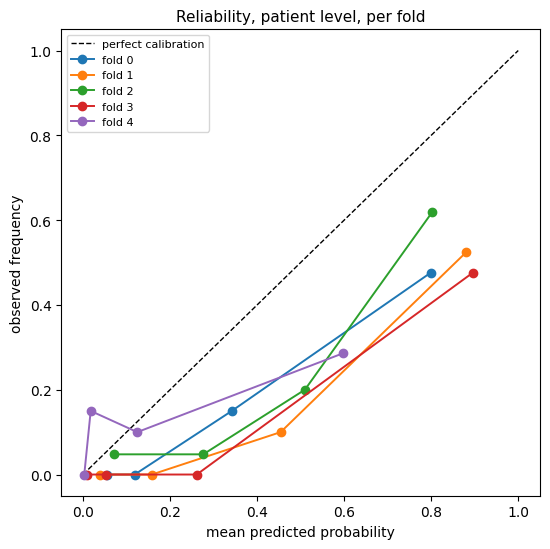

pooled patient-level Brier (raw): 0.1332


In [ ]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
for f, d in pt.groupby("fold"):
    frac, mean_pred = calibration_curve(d.label, d.prob, n_bins=4, strategy="quantile")
    ax.plot(mean_pred, frac, "o-", lw=1.4, label=f"fold {f}")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Reliability, patient level, per fold", fontsize=11)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"pooled patient-level Brier (raw): {brier_score_loss(pt.label, pt.prob):.4f}")

In [ ]:
def op_table(y, p, thresholds, label="threshold"):
    """Operating points at fixed score thresholds, with NPV and workload counts."""
    print(f"{label:>10} {'sens':>7} {'spec':>7} {'PPV':>7} {'NPV':>7} "
          f"{'missed':>7} {'flagged':>8} {'cleared':>8}")
    for t in thresholds:
        pr = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, pr, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else float("nan")
        spec = tn / (tn + fp) if (tn + fp) else float("nan")
        ppv  = tp / (tp + fp) if (tp + fp) else float("nan")
        npv  = tn / (tn + fn) if (tn + fn) else float("nan")
        print(f"{t:>10.4f} {sens:>7.1%} {spec:>7.1%} {ppv:>7.1%} {npv:>7.1%} "
              f"{fn:>7d} {tp+fp:>8d} {tn+fn:>8d}")


def sens_targets(y, p, targets=(0.90, 0.95, 0.98)):
    """Specificity at fixed sensitivity floors — how MSIntuit reports."""
    fpr, tpr, thr = roc_curve(y, p)
    print(f"{'target':>8} {'thresh':>9} {'sens':>7} {'spec':>7} {'missed':>7} {'ruled_out':>11}")
    for t in targets:
        i = np.where(tpr >= t)[0][0]
        n_pos_, n_neg_ = int(y.sum()), int((y == 0).sum())
        print(f"{t:>8.0%} {thr[i]:>9.4f} {tpr[i]:>7.1%} {1-fpr[i]:>7.1%} "
              f"{round((1-tpr[i])*n_pos_):>7d} {round((1-fpr[i])*n_neg_):>7d}/{n_neg_}")


print("RAW scores — thresholds are raw probabilities pooled across five folds.")
print("These are shown to document the artifact, NOT as a usable rule.\n")
op_table(pt.label.values, pt.prob.values, [0.5, 0.25, 0.1, 0.05, 0.005, 0.001])
print()
sens_targets(pt.label.values, pt.prob.values)
print()
print("A threshold of 0.005 is deep in the tail for the low-scoring folds and")
print("below everything in the high-scoring folds, so it flags entire folds")
print("wholesale. The resulting specificity is an artifact of pooling, not a")
print("property of the model.")

RAW scores — thresholds are raw probabilities pooled across five folds.
These are shown to document the artifact, NOT as a usable rule.

 threshold    sens    spec     PPV     NPV  missed  flagged  cleared
    0.5000   83.3%   80.9%   45.5%   96.2%      11      121      290
    0.2500   89.4%   64.1%   32.2%   96.9%       7      183      228
    0.1000   93.9%   45.5%   24.8%   97.5%       4      250      161
    0.0500   93.9%   29.3%   20.3%   96.2%       4      306      105
    0.0050  100.0%    8.4%   17.3%  100.0%       0      382       29
    0.0010  100.0%    1.7%   16.3%  100.0%       0      405        6

  target    thresh    sens    spec  missed   ruled_out
     90%    0.2364   90.9%   62.0%       6     214/345
     95%    0.0328   97.0%   21.4%       2      74/345
     98%    0.0200   98.5%   15.7%       1      54/345

A threshold of 0.005 is deep in the tail for the low-scoring folds and
below everything in the high-scoring folds, so it flags entire folds
wholesale. The res

### B. Out-of-fold calibrated scores

`pt.cal` comes from a Platt calibrator fitted on the inner-val slice of each
training fold and applied to the untouched test fold. Nothing from the test fold
informed the model, the epoch count, or the calibration.

That fixes the leak in the earlier version, where the calibrator was fitted on
evaluation-fold labels via a cross-fitted inner split. Cross-fitting made each
*individual* prediction honest, but AUROC averages over **pairs**: patient *i*
was scored by a calibrator trained on a half containing *j*'s label, and *j* by
one containing *i*'s. Fitting inside the training fold removes that.

**Two things the fix does NOT buy, both of which must be stated:**

1. **The operating point is still selected post hoc.** Reading a threshold off
   the ROC at a 95% sensitivity target uses the test labels to find where the
   curve crosses. The *target* is an a priori policy choice — rule-out screening
   demands high sensitivity — but the *specificity reported at that point* is
   optimistic. Call it "operating point read off post hoc at a pre-specified
   sensitivity target", never "deployable" or "validated".
2. **The inner-val patients do double duty.** They select the epoch *and* fit
   the calibrator. Epoch selection picks the checkpoint that looks best on those
   specific patients, so their predictions are optimistically good, so the
   calibrator fits a mapping assuming better-separated inputs than it meets on
   the test fold. It therefore **under-corrects**, and the calibrated
   probabilities stay slightly overconfident. The obvious fix — split inner-val
   in half — would leave ~41 patients and ~7 positives per half, which is where
   negative Platt slopes come from. That trades a small known bias for a large
   unknown variance. Not worth it; disclose it instead.

**Two things to check in the output:**

- Per-fold Platt slopes. A slope below 1 means the calibrator is shrinking
  logits toward the base rate, i.e. the raw scores were overconfident. A slope
  at or below 0 would invert that fold's ranking; the loop falls back to raw
  scores if that happens.
- Calibration is monotone within a fold, so it **cannot** change within-fold
  AUROC. Macro raw and macro calibrated must be identical to several decimals.

In [ ]:
base   = pt.label.mean()
bs_ref = base * (1 - base)

print(f"{'':14s} {'AUROC (macro)':>14} {'AUROC (pooled)':>15} {'Brier':>8} {'BSS':>8}")
for name, col in [("raw", "prob"), ("calibrated", "cal")]:
    mac, mic, _ = macro_micro(pt, score_col=col)
    bs = brier_score_loss(pt.label, pt[col])
    print(f"{name:14s} {mac:>14.4f} {mic:>15.4f} {bs:>8.4f} {1 - bs/bs_ref:>+8.3f}")

lo_c, hi_c, _ = boot_auc(pt.label.values, pt.cal.values)
print(f"\ncalibrated pooled AUROC 95% CI: [{lo_c:.3f}, {hi_c:.3f}]")

# --- Calibrator stability. Fitted on ~13 positives, so check it per fold. -----
slopes = pt.groupby("fold").agg(platt_slope=("platt_slope", "first"),
                                platt_used=("platt_used", "first"),
                                n_MSI_H=("label", "sum"))
print("\nPer-fold Platt slope (a slope <= 0 would invert that fold's ranking):")
print(slopes.round(3).to_string())
if not slopes.platt_used.all():
    bad = slopes.index[~slopes.platt_used].tolist()
    print(f"\n*** Folds {bad} fell back to raw scores: the calibrator fitted a")
    print("non-positive slope on a small inner-val set. This is a finding about")
    print("calibration-set size, not a bug. Report it. ***")

# --- Monotonicity check -------------------------------------------------------
# Platt is monotone WITHIN a fold, so it cannot change within-fold AUROC. Any
# change in POOLED AUROC is therefore pure cross-fold scale alignment.
mac_raw, _, _ = macro_micro(pt, score_col="prob")
mac_cal, _, _ = macro_micro(pt, score_col="cal")
print(f"\nSanity: macro raw {mac_raw:.6f} vs macro calibrated {mac_cal:.6f} "
      f"(diff {mac_cal-mac_raw:+.6f})")
if abs(mac_raw - mac_cal) < 1e-6:
    print("Identical, as required. Any change in POOLED AUROC is scale alignment")
    print("across folds and nothing else.")
elif mac_cal < mac_raw - 0.01:
    print("*** Macro DROPPED. A calibrator inverted a fold's ranking. Check the")
    print("slope table above — a non-positive slope is the usual cause. ***")
else:
    print("*** Macro changed. Platt is monotone within a fold, so it cannot:")
    print("this means the calibrator was fitted or applied ACROSS folds. ***")

                AUROC (macro)  AUROC (pooled)    Brier      BSS
raw                    0.8946          0.8761   0.1332   +0.012
calibrated             0.8946          0.8754   0.0837   +0.379

calibrated pooled AUROC 95% CI: [0.821, 0.925]

Per-fold Platt slope (a slope <= 0 would invert that fold's ranking):
      platt_slope  platt_used  n_MSI_H
fold                                  
0           1.154        True       13
1           0.717        True       13
2           1.251        True       19
3           0.685        True       10
4           1.018        True       11

Sanity: macro raw 0.894629 vs macro calibrated 0.894629 (diff +0.000000)
Identical, as required. Any change in POOLED AUROC is scale alignment
across folds and nothing else.


In [ ]:
print("CALIBRATED scores — out-of-fold, thresholds are interpretable probabilities.\n")
sens_targets(pt.label.values, pt.cal.values)
print()
op_table(pt.label.values, pt.cal.values, [0.5, 0.3, 0.2, 0.15, 0.10, 0.07, 0.05])
print()
print(f"PPV and NPV are computed at THIS cohort's prevalence ({base:.1%}) and do")
print("not transport. Sensitivity and specificity do. See the next cell.")
print()
print("The SCORES are out-of-fold: no test-fold label informed the model, the")
print("epoch count, or the calibration. The OPERATING POINT is not — the threshold")
print("is read off this ROC, so the specificity at any chosen sensitivity is")
print("optimistic. Report as: 'operating point read off post hoc at a")
print("pre-specified sensitivity target'.")

CALIBRATED scores — out-of-fold, thresholds are interpretable probabilities.

  target    thresh    sens    spec  missed   ruled_out
     90%    0.0362   90.9%   55.4%       6     191/345
     95%    0.0079   95.5%   22.6%       3      78/345
     98%    0.0021   98.5%    9.9%       1      34/345

 threshold    sens    spec     PPV     NPV  missed  flagged  cleared
    0.5000   51.5%   96.8%   75.6%   91.3%      32       45      366
    0.3000   69.7%   90.7%   59.0%   94.0%      20       78      333
    0.2000   75.8%   83.8%   47.2%   94.8%      16      106      305
    0.1500   84.8%   81.4%   46.7%   96.6%      10      120      291
    0.1000   89.4%   75.1%   40.7%   97.4%       7      145      266
    0.0700   89.4%   67.0%   34.1%   97.1%       7      173      238
    0.0500   89.4%   59.4%   29.6%   96.7%       7      199      212

PPV and NPV are computed at THIS cohort's prevalence (16.1%) and do
not transport. Sensitivity and specificity do. See the next cell.

The SCORES ar

**Why NPV is the number this use case lives on.** Flagged patients go on to
IHC/PCR anyway, so a false positive costs one unnecessary confirmatory test.
Cleared patients are never tested again, so a false negative is a patient who
silently never gets pembrolizumab.

PPV and NPV are properties of the test *applied to a population*, because Bayes'
theorem drags prevalence into them. Sensitivity and specificity are properties
of the test alone. This matters: TCGA-COAD sits near 16% MSI-H, but metastatic
CRC is nearer 5%, and dropping the rectal cases at the Section 3 join pushed
this cohort's prevalence *above* a true CRC screening population.

In [ ]:
def npv_at(sens, spec, prevalence):
    tn_ = spec * (1 - prevalence)
    fn_ = (1 - sens) * prevalence
    return tn_ / (tn_ + fn_)

def ppv_at(sens, spec, prevalence):
    tp_ = sens * prevalence
    fp_ = (1 - spec) * (1 - prevalence)
    return tp_ / (tp_ + fp_)

fpr, tpr, thr = roc_curve(pt.label, pt.cal)
i = np.where(tpr >= 0.95)[0][0]
sens_op, spec_op = tpr[i], 1 - fpr[i]
print(f"Out-of-fold calibrated scores; operating point read off post hoc at a")
print(f"pre-specified 95% sensitivity target: sens {sens_op:.1%}, "
      f"spec {spec_op:.1%}, threshold {thr[i]:.4f}\n")

print(f"{'prevalence':>11} {'PPV':>7} {'NPV':>7} {'miss rate among cleared':>25}")
for pi in [base, 0.10, 0.05]:
    print(f"{pi:>11.1%} {ppv_at(sens_op, spec_op, pi):>7.1%} "
          f"{npv_at(sens_op, spec_op, pi):>7.1%} "
          f"{1-npv_at(sens_op, spec_op, pi):>25.1%}")

Out-of-fold calibrated scores; operating point read off post hoc at a
pre-specified 95% sensitivity target: sens 95.5%, spec 22.6%, threshold 0.0079

 prevalence     PPV     NPV   miss rate among cleared
      16.1%   19.1%   96.3%                      3.7%
      10.0%   12.1%   97.8%                      2.2%
       5.0%    6.1%   99.0%                      1.0%


### C. Label-free threshold construction

Part B's thresholds come from reading the ROC. This check builds thresholds
without labels at all: `np.quantile()` on each fold's own raw scores, so the
cutoff is "flag the top N% of this fold" and labels appear only when scoring the
result.

**The threshold construction is label-free; the choice of which row to quote is
not.** Selecting the row nearest a 95% sensitivity target still reads the test
labels. So this is corroboration of part B's shape, not an escape from post-hoc
selection.

Watch for a cliff between the ~90% and ~95% sensitivity rows. At high
sensitivity the cutoff is pinned by the single lowest-scoring positive in each
fold, so a handful of atypical patients can cost most of the specificity.

In [ ]:
# C1. Within-fold only: never compares a score from one model against another.
print("C1 — specificity at a ~94% sensitivity floor, computed WITHIN each fold\n")
print(f"{'fold':>5} {'n_MSS':>6} {'n_MSI_H':>8} {'sens':>7} {'spec':>7}")
specs = []
for f, d in pt.groupby("fold"):
    fpr_, tpr_, _ = roc_curve(d.label, d.prob)
    i = np.where(tpr_ >= 0.939)[0][0]
    specs.append(1 - fpr_[i])
    print(f"{f:>5} {int((d.label==0).sum()):>6} {int(d.label.sum()):>8} "
          f"{tpr_[i]:>7.1%} {1-fpr_[i]:>7.1%}")
print(f"\nmean per-fold specificity: {np.mean(specs):.1%}  "
      f"(range {np.min(specs):.1%} - {np.max(specs):.1%})")
print()
print("Two things to read here, not one:")
print("  * The MEAN is a CONSERVATIVE ESTIMATE, not a mathematical bound. With")
print("    ~10-19 positives per fold the ROC is coarse — there is often no rung")
print("    at exactly 93.9%, so folds overshoot to 100% sensitivity and are")
print("    scored at a stricter standard than the target.")
print("  * The SPREAD is the real finding. At high sensitivity the threshold is")
print("    set by the single lowest-scoring positive in each fold, so one")
print("    atypical patient dominates. That instability is the honest estimate")
print("    of deployment risk, and it is why per-site calibration exists.")

C1 — specificity at a ~94% sensitivity floor, computed WITHIN each fold

 fold  n_MSS  n_MSI_H    sens    spec
    0     69       13  100.0%   82.6%
    1     69       13  100.0%   75.4%
    2     64       19   94.7%   40.6%
    3     72       10  100.0%   84.7%
    4     71       11  100.0%   36.6%

mean per-fold specificity: 64.0%  (range 36.6% - 84.7%)

Two things to read here, not one:
  * The MEAN is a CONSERVATIVE ESTIMATE, not a mathematical bound. With
    ~10-19 positives per fold the ROC is coarse — there is often no rung
    at exactly 93.9%, so folds overshoot to 100% sensitivity and are
    scored at a stricter standard than the target.
  * The SPREAD is the real finding. At high sensitivity the threshold is
    set by the single lowest-scoring positive in each fold, so one
    atypical patient dominates. That instability is the honest estimate
    of deployment risk, and it is why per-site calibration exists.


In [ ]:
# C2. Per-fold quantile thresholds on RAW scores: same cutoff quantile,
#     each fold's own scale. No ranks, no Platt.
print("C2 — flag a fixed fraction of each fold, using that fold's own scale\n")
rows = []
for top_frac in [0.20, 0.30, 0.40, 0.50, 0.60]:
    flags = np.zeros(len(pt), dtype=int)
    for f in pt.fold.unique():
        m = (pt.fold == f).values
        cut = np.quantile(pt.prob.values[m], 1 - top_frac)
        flags[m] = (pt.prob.values[m] >= cut).astype(int)
    tn, fp, fn, tp = confusion_matrix(pt.label, flags, labels=[0, 1]).ravel()
    rows.append({"flag_top": top_frac,
                 "sens": tp/(tp+fn), "spec": tn/(tn+fp),
                 "NPV": tn/(tn+fn) if (tn+fn) else np.nan,
                 "missed": fn, "flagged": tp+fp, "cleared": tn+fn})
print(pd.DataFrame(rows).round(3).to_string(index=False))

C2 — flag a fixed fraction of each fold, using that fold's own scale

 flag_top  sens  spec   NPV  missed  flagged  cleared
      0.2 0.697 0.887 0.939      20       85      326
      0.3 0.818 0.794 0.958      12      125      286
      0.4 0.924 0.699 0.980       5      165      246
      0.5 0.924 0.580 0.976       5      206      205
      0.6 0.955 0.470 0.982       3      246      165


### Convergence summary

In [ ]:
# C2 sweep — label-free threshold construction, for comparison against part B.
c2_rows = []
for top_frac in np.arange(0.20, 0.85, 0.05):
    flags = np.zeros(len(pt), dtype=int)
    for f in pt.fold.unique():
        m = (pt.fold == f).values
        cut = np.quantile(pt.prob.values[m], 1 - top_frac)
        flags[m] = (pt.prob.values[m] >= cut).astype(int)
    tn, fp, fn, tp = confusion_matrix(pt.label, flags, labels=[0, 1]).ravel()
    c2_rows.append((top_frac, tp/(tp+fn), tn/(tn+fp)))

def c2_at(floor):
    return next((r for r in c2_rows if r[1] >= floor), None)

mac_raw, mic_raw, pf_raw = macro_micro(pt, score_col="prob")
mac_cal, mic_cal, _      = macro_micro(pt, score_col="cal")
lo_m, hi_m, _ = boot_macro(pt, "prob")

fpr_r, tpr_r, _ = roc_curve(pt.label, pt.prob)
fpr_c, tpr_c, _ = roc_curve(pt.label, pt.cal)

print(f"RUN: {RUN_TAG}\n")
print(f"{'estimate':<40} {'AUROC':>7} {'test labels?':>14} {'transductive?':>15}")
print(f"{'macro (mean per-fold)  <-- HEADLINE':<40} {mac_raw:>7.3f} {'no':>14} {'no':>15}")
print(f"{'pooled, out-of-fold calibrated':<40} {mic_cal:>7.3f} {'no':>14} {'no':>15}")
print(f"{'pooled, rank-normalised':<40} {auc_r:>7.3f} {'no':>14} {'yes':>15}")
print(f"{'pooled, naive raw scores':<40} {mic_raw:>7.3f} {'no':>14} {'no':>15}")
print(f"{'mean-pool baseline (macro)':<40} {b_macro:>7.3f} {'no':>14} {'no':>15}")
print(f"\nHEADLINE: macro {mac_raw:.3f}  95% CI [{lo_m:.3f}, {hi_m:.3f}]  "
      f"(fold range {pf_raw.min():.3f}-{pf_raw.max():.3f}, SD {pf_raw.std(ddof=1):.3f})")

print(f"\nOperating points. ALL are read off post hoc — the threshold is chosen")
print(f"by looking at where each curve crosses the sensitivity target.\n")
print(f"{'':26} {'sens':>7} {'spec':>7}")
for floor in (0.90, 0.95):
    ir = np.where(tpr_r >= floor)[0][0]
    ic = np.where(tpr_c >= floor)[0][0]
    c2 = c2_at(floor)
    print(f"  target {floor:.0%}")
    print(f"{'    naive pooled raw':26} {tpr_r[ir]:>7.1%} {1-fpr_r[ir]:>7.1%}   (artifact)")
    print(f"{'    OOF calibrated':26} {tpr_c[ic]:>7.1%} {1-fpr_c[ic]:>7.1%}   <-- primary")
    if c2:
        print(f"{'    C2 per-fold quantile':26} {c2[1]:>7.1%} {c2[2]:>7.1%}   (label-free thresholds)")

print()
print("HEADLINE DISCRIMINATION : macro AUROC, with fold range and SD. No labels")
print("  beyond within-fold ordering, no whole-cohort information, no test-fold")
print("  leakage. Quote it as a range, not a bare decimal.")
print("OPERATING POINTS: out-of-fold SCORES, but the threshold is read off these")
print("  curves, so every specificity above is optimistic. Not 'deployable', not")
print("  'validated'. If the 90% and 95% rows differ sharply, report BOTH and say")
print("  so -- the cliff is a real property of the model, not a presentation choice.")
print()
print("Unfixed by this design: post-hoc operating point; inner-val patients do")
print("double duty (epoch selection + calibration), so calibrated probabilities")
print("are slightly overconfident; single cohort, no external validation.")

RUN: main

estimate                                   AUROC   test labels?   transductive?
macro (mean per-fold)  <-- HEADLINE        0.895             no              no
pooled, out-of-fold calibrated             0.875             no              no
pooled, rank-normalised                    0.890             no             yes
pooled, naive raw scores                   0.876             no              no
mean-pool baseline (macro)                 0.879             no              no

HEADLINE: macro 0.895  95% CI [0.850, 0.934]  (fold range 0.776-0.957, SD 0.075)

Operating points. ALL are read off post hoc — the threshold is chosen
by looking at where each curve crosses the sensitivity target.

                              sens    spec
  target 90%
    naive pooled raw         90.9%   62.0%   (artifact)
    OOF calibrated           90.9%   55.4%   <-- primary
    C2 per-fold quantile     92.4%   69.9%   (label-free thresholds)
  target 95%
    naive pooled raw         97.0%   21.4

---

# Section 9 — Controls, figure, summary

### Site as a shortcut

TCGA slides carry a site signature: each submitting institution has its own
fixation protocol, stain lot, scanner and section thickness. If MSI-H prevalence
were enriched at particular sites, a model could score well by learning the
institution rather than the biology.

This experiment asks only: **is MSI-H correlated with site?** It does not ask
whether the model can recognise site-specific staining or scanning artifacts —
batch effects do not require label correlation. Leave-one-site-out CV is the
experiment that would settle that, and it is not run here.

In [ ]:
from scipy import stats

site_tbl = (manifest.groupby("site_id")["label"]
            .agg(prevalence="mean", n_MSI_H="sum", n_slides="count")
            .query("n_slides >= 10")
            .sort_values("prevalence", ascending=False))
print(site_tbl.round(3).to_string())

pos, n = site_tbl.n_MSI_H.values, site_tbl.n_slides.values
chi2, pval, dof, _ = stats.chi2_contingency(np.array([pos, n - pos]))

# Parametric bootstrap: is the observed spread wider than chance, at these
# site sizes and this base rate?
p0 = pos.sum() / n.sum()
rng = np.random.default_rng(0)
null = []
for _ in range(10_000):
    sim = rng.binomial(n, p0)
    null.append(stats.chi2_contingency(np.array([sim, n - sim]))[0])
boot_p = float(np.mean(np.array(null) >= chi2))

print(f"\ncohort slide-level prevalence : {manifest['label'].mean():.1%}")
print(f"range across sites with >=10 slides: "
      f"{site_tbl.prevalence.min():.1%} - {site_tbl.prevalence.max():.1%}")
print(f"chi-square: {chi2:.2f} (dof {dof}), p = {pval:.3f}   "
      f"parametric bootstrap p = {boot_p:.3f}")
print()
print("Prevalence varies widely across sites, but that spread is consistent with")
print("chance at these site sizes and this base rate: a site with 13 slides lands")
print("at 0/13 or 5/13 fairly often with no enrichment at all. Label-site")
print("correlation is NOT detectable here.")
print()
print("This does not establish whether site-specific artifacts contribute to")
print("model performance. That requires leave-one-site-out CV.")

         prevalence  n_MSI_H  n_slides
site_id                               
AD            0.385        5        13
CK            0.286        4        14
G4            0.208        5        24
A6            0.196        9        46
CM            0.162        6        37
D5            0.161        5        31
AA            0.147       21       143
F4            0.125        2        16
AZ            0.125        2        16
AY            0.100        1        10
NH            0.100        1        10
CA            0.000        0        10
DM            0.000        0        23

cohort slide-level prevalence : 16.0%
range across sites with >=10 slides: 0.0% - 38.5%
chi-square: 14.98 (dof 12), p = 0.243   parametric bootstrap p = 0.239

Prevalence varies widely across sites, but that spread is consistent with
chance at these site sizes and this base rate: a site with 13 slides lands
at 0/13 or 5/13 fairly often with no enrichment at all. Label-site
correlation is NOT detectable here.

T

---

## Section 9b — Does the score track the continuous phenotype?

The binary label came from thresholding a continuous MSIsensor score at 10. That
raises a question AUROC cannot answer: **is the model learning the arbitrary
cutoff, or the underlying degree of microsatellite instability?**

If the model score correlates with the continuous MSIsensor value — including
*within* the MSS group, where every patient shares the same binary label — then
it has learned something about instability itself rather than a decision
boundary. That is a construct-validity claim, and a stronger one than a
thresholded AUROC.

No GPU. Run it while a longer run trains.

In [ ]:
from scipy import stats

sc = (labels.set_index("PATIENT_ID")["MSIsensor Score"]
            .reindex(pt.patient_id).values)
d = pt.assign(msisensor=sc).dropna(subset=["msisensor"])
print(f"{len(d)}/{len(pt)} patients matched to a continuous MSIsensor score\n")

rho_all, p_all = stats.spearmanr(d.cal, d.msisensor)
mss = d[d.label == 0]
rho_mss, p_mss = stats.spearmanr(mss.cal, mss.msisensor)

print(f"Spearman, all patients        : rho {rho_all:+.3f}  (p {p_all:.2g}, n {len(d)})")
print(f"Spearman, MSS patients only   : rho {rho_mss:+.3f}  (p {p_mss:.2g}, n {len(mss)})")
print()
print("The second line is the informative one. Every patient in it has the SAME")
print("binary label, so any correlation cannot come from learning the cutoff.")

# Grey-zone sensitivity: how much of the error sits near the boundary?
grey = d[(d.msisensor >= 3.5) & (d.msisensor < 10)]
clean = d[(d.msisensor < 3.5) | (d.msisensor >= 10)]
print(f"\nGrey zone (3.5 <= MSIsensor < 10): {len(grey)} patients")
if len(grey) and clean.label.nunique() == 2:
    print(f"  macro AUROC, all patients        : "
          f"{macro_micro(d, 'prob')[0]:.3f}")
    print(f"  macro AUROC, grey zone excluded  : "
          f"{macro_micro(clean, 'prob')[0]:.3f}")
    print("  A rise means some 'errors' were borderline-instability tumours,")
    print("  i.e. label-boundary noise rather than model failure.")

# The hardest positives: which MSI-H patients does the model rank lowest?
hard = d[d.label == 1].nsmallest(6, "cal")[["patient_id", "cal", "msisensor", "fold"]]
print("\nLowest-scoring MSI-H patients (these set the high-sensitivity threshold):")
print(hard.round(4).to_string(index=False))
print()
print("If these cluster just above MSIsensor 10, the specificity cliff at high")
print("sensitivity is largely a label-boundary artifact and can be reported as")
print("such. If they sit at 30+, they are genuine failures worth pulling slides")
print("for. Either answer is publishable; state which one you got.")

411/411 patients matched to a continuous MSIsensor score

Spearman, all patients        : rho +0.279  (p 8.5e-09, n 411)
Spearman, MSS patients only   : rho -0.042  (p 0.43, n 345)

The second line is the informative one. Every patient in it has the SAME
binary label, so any correlation cannot come from learning the cutoff.

Grey zone (3.5 <= MSIsensor < 10): 6 patients
  macro AUROC, all patients        : 0.895
  macro AUROC, grey zone excluded  : 0.899
  A rise means some 'errors' were borderline-instability tumours,
  i.e. label-boundary noise rather than model failure.

Lowest-scoring MSI-H patients (these set the high-sensitivity threshold):
  patient_id    cal  msisensor  fold
TCGA-G4-6320 0.0018      14.97     2
TCGA-AA-A00N 0.0021      32.47     4
TCGA-NH-A5IV 0.0047      41.02     4
TCGA-QG-A5Z2 0.0079      19.29     4
TCGA-A6-5656 0.0278      15.42     2
TCGA-AD-6889 0.0282      40.44     4

If these cluster just above MSIsensor 10, the specificity cliff at high
sensitivity i

### Figure — what the calibration correction buys

Raw and calibrated ROC on the same axes, with the 95%-sensitivity operating
point marked on each. The point of the figure is the *difference between the
two curves' operating points*, not either curve alone.

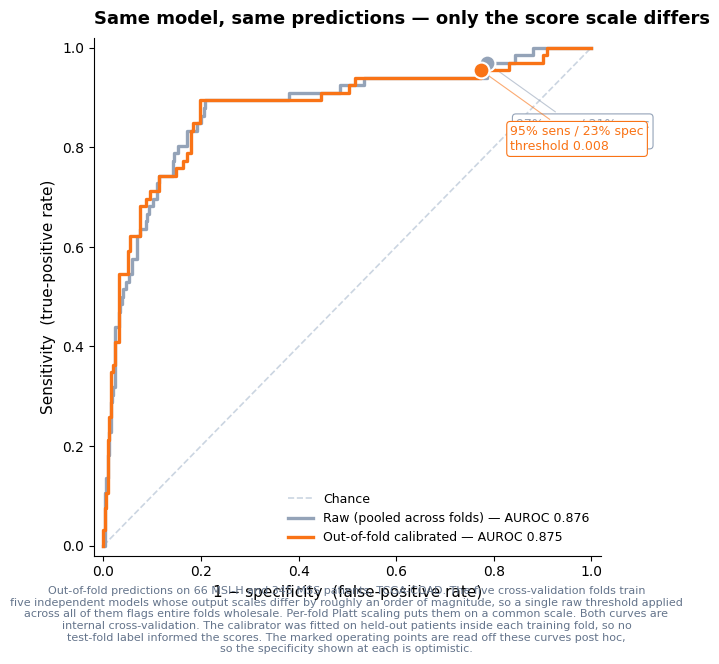

saved fig_roc_main.png / .svg


In [ ]:
plt.rcParams.update({"font.family": "DejaVu Sans", "svg.fonttype": "none",
                     "axes.spines.top": False, "axes.spines.right": False})

y = pt.label.values
curves = {
    "Raw (pooled across folds)": (pt.prob.values, "#94a3b8"),
    "Out-of-fold calibrated": (pt.cal.values, "#f97316"),
}

fig, ax = plt.subplots(figsize=(6.4, 6.2))
ax.plot([0, 1], [0, 1], color="#cbd5e1", ls="--", lw=1.2, label="Chance")

marks = {}
for name, (p, colr) in curves.items():
    fpr_, tpr_, thr_ = roc_curve(y, p)
    auc_ = roc_auc_score(y, p)
    ax.plot(fpr_, tpr_, color=colr, lw=2.4, zorder=4, label=f"{name} — AUROC {auc_:.3f}")
    i = np.where(tpr_ >= 0.95)[0][0]
    marks[name] = (fpr_[i], tpr_[i], 1 - fpr_[i], thr_[i], colr)
    ax.scatter([fpr_[i]], [tpr_[i]], s=130, color=colr, zorder=6,
               edgecolor="white", linewidth=1.5)

for k, (fx, ty, spec, th, colr) in marks.items():
    ax.annotate(f"{ty:.0%} sens / {spec:.0%} spec\nthreshold {th:.3f}",
                xy=(fx, ty), xytext=(fx + 0.06, ty - 0.16),
                fontsize=9, color=colr,
                arrowprops=dict(arrowstyle="-", color=colr, lw=0.8, alpha=0.6),
                bbox=dict(boxstyle="round,pad=0.28", fc="white", ec=colr, lw=0.8))

ax.set_xlabel("1 − specificity  (false-positive rate)", fontsize=11)
ax.set_ylabel("Sensitivity  (true-positive rate)", fontsize=11)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_title("Same model, same predictions — only the score scale differs",
             fontsize=13, fontweight="bold", loc="left", pad=10)
ax.legend(loc="lower right", fontsize=9, frameon=False)

fig.text(0.5, -0.06,
         f"Out-of-fold predictions on {int(y.sum())} MSI-H and {int((y==0).sum())} MSS "
         "patients, TCGA-COAD. The five cross-validation folds train\nfive independent "
         "models whose output scales differ by roughly an order of magnitude, so a single "
         "raw threshold applied\nacross all of them flags entire folds wholesale. "
         "Per-fold Platt scaling puts them on a common scale. Both curves are\ninternal "
         "cross-validation. The calibrator was fitted on held-out patients inside each "
         "training fold, so no\ntest-fold label informed the scores. The marked operating points are read off "
         "these curves post hoc,\nso the specificity shown at each is optimistic.",
         fontsize=8, color="#64748b", ha="center")

fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/fig_roc_{RUN_TAG}.png", bbox_inches="tight", dpi=200)
fig.savefig(f"{SAVE_DIR}/fig_roc_{RUN_TAG}.svg", bbox_inches="tight")
plt.show()
print(f"saved fig_roc_{RUN_TAG}.png / .svg")

### Save out-of-fold predictions

In [ ]:
oof.to_csv(f"{SAVE_DIR}/oof_{RUN_TAG}.csv", index=False)
pt.to_csv(f"{SAVE_DIR}/pt_{RUN_TAG}.csv", index=False)
fold_tbl.to_csv(f"{SAVE_DIR}/per_fold_{RUN_TAG}.csv", index=False)
print(f"Saved all artifacts for run '{RUN_TAG}' to {SAVE_DIR}")
print("\nNow change RUN_TAG (and its switches) in Step 1 and run the notebook again.")
print("When the runs are done, run Section 10 to compare them.")

Saved all artifacts for run 'main' to /content/drive/MyDrive/TCGA_COAD

Now change RUN_TAG (and its switches) in Step 1 and run the notebook again.
When the runs are done, run Section 10 to compare them.


---

## Headline results

| | value | basis |
|---|---|---|
| **Discrimination** | macro AUROC + fold range + SD (Section 6 Step 5) | mean of five per-fold patient-level AUROCs, with a cluster-bootstrap CI. No labels beyond within-fold ordering, no whole-cohort information. |
| Corroboration | rank-normalised pooled | label-free; recovers ~93% of the pooling gap |
| **Operating point** | out-of-fold calibrated, reported at BOTH 90% and 95% sens (Section 8B) | scores are out-of-fold; the threshold is read off the ROC post hoc, so each specificity is optimistic |
| **Baseline** | mean-pool + logistic regression (Section 7b) | same folds. If the delta is inside the fold-to-fold SD, attention is not demonstrably earning its parameters — report that plainly. |
| Artifact, documented | naively pooled raw scores | one raw threshold across five incompatible score scales |
| Label-free thresholds | C2 per-fold quantiles (Section 8C) | thresholds from `np.quantile`; the row quoted is still chosen post hoc |

Describe the low pooled figure as **naively pooled raw-score AUROC**, not "the
model's AUROC", and the macro figure as **mean per-fold patient-level AUROC**,
not "the true AUROC". Both are estimates; they answer different questions.

## What was checked

- **Patient-level splitting** — asserted in every fold; no patient on both sides.
  A second assertion confirms each patient lives in exactly one fold before any
  patient-level aggregation.
- **One row per patient in the clinical table** — asserted, so a duplicated
  patient cannot silently inflate the cohort at the many-to-one merge.
- **Every slide predicted out-of-fold exactly once** — `len(oof) == len(manifest)`.
- **CLAM implementation pinned** by commit hash.
- **Permuted-label control** — labels shuffled at patient level, full CV rerun
  with `PERMUTE_LABELS = True`. *Re-run this and paste the current number before
  publishing; the previously recorded 0.509 [0.436, 0.588] came from an earlier
  session and is the one figure here not reproducible from this notebook.*
- **Scale drift, isolated** — macro vs micro AUROC compared at matched
  aggregation level, so the gap is attributable to pooling rather than to
  slide-vs-patient aggregation.
- **Three independent corrections agree** — macro (label-free, not transductive),
  rank-normalisation (label-free, transductive), and per-fold quantile
  thresholding (label-free). Platt agrees too but uses evaluation labels.
- **Label separation quantified** — grey-zone count either side of the cutoff.
- **Site as a shortcut** — prevalence by tissue source site, with a chi-square
  and parametric bootstrap rather than an eyeball judgement.

## Known limitations

- **Single cohort (TCGA-COAD).** No external validation, so no generalisation
  claim. Published work consistently shows large drops from in-cohort CV to true
  external validation; these numbers are the easier quantity.
- **Colon only.** Rectal cases drop at the Section 3 join, which raises this
  cohort's MSI-H prevalence above a true CRC screening population and inflates
  every PPV.
- **Labels are MSIsensor >= 10**, a computational NGS score, not the MMR-IHC /
  MSI-PCR clinical reference standard used by the tools compared against. The
  grey zone is small, so this label is likely *easier* than a clinical one.
- **Calibration sets are small.** The Platt calibrator is fitted on ~82 inner-val
  patients with ~13 positives. Honest, but noisy: this design relocates the
  variance rather than removing it. MSIntuit assumes ~30 calibration slides per
  scanner for the same reason.
- **Inner-val patients do double duty** — epoch selection *and* calibration.
  Epoch selection picks the checkpoint that looks best on those patients, so
  their predictions are optimistically good, so the calibrator under-corrects
  and the calibrated probabilities stay slightly overconfident. Splitting
  inner-val again would leave ~7 positives per half, trading a small known bias
  for a large unknown variance.
- **Every operating point is read off post hoc.** The sensitivity target is an
  a priori policy choice; the specificity reported at it is not. This applies to
  the calibrated table and the C2 table alike.
- **Training uses 75% of each training fold**, since the inner split is carved
  out of it. AUROC is therefore slightly below what the full-fold version
  reported; that is the correct number, not a regression.
- **Attention is not demonstrably better than mean pooling** on this cohort. See
  Section 7b: report the delta against the fold-to-fold SD, not on its own.
- **No cross-site split.** Distribution shift unquantified. The per-fold
  specificity spread in Section 8C is the closest proxy and it is wide
  (14%-88% at maximum sensitivity), driven by the single lowest-scoring positive
  in each fold.
- **Epoch count** is now selected per fold on inner-val loss, so the earlier
  test-set contamination is gone. The selected epochs are logged per run.
- **Fold prevalence varies 12.2%-22.9%**, so BSS is not comparable across folds:
  the reference Brier is p(1-p), which shrinks as p moves away from 0.5.
- **No clinical baseline** (tumour sidedness, age, sex, mucinous histology).
- **One metastatic slide** (`sample_type == "06"`) retained. One of 419; changes
  nothing, recorded so the choice is explicit.

## Not run

Nested calibration, epoch selection, site-grouped CV and the frozen-projection
ablation are all now runnable from this notebook via `RUN_TAG`. What remains:

1. **`RUN_TAG = "sitegrouped"`** — the highest-value remaining run. Every reader
   who knows the TCGA site-signature literature will ask whether the result
   survives when the model cannot see familiar institutions, and "I built the
   experiment but did not run it" is weaker than either answer. Start it, then
   write Section 9b while it trains — they do not compete for the GPU.
2. **`RUN_TAG = "permuted"`** — makes the notebook self-contained. The control
   currently quoted comes from an earlier session.
3. **External cohort** — CPTAC-COAD via TCIA, PAIP 2020, MCO-CRC. The only thing
   that would license a generalisation claim.
4. **Attention heatmaps** on the highest- and lowest-scoring patients — though
   note Section 7b may have already shown attention is not doing much, which
   makes this less interesting than it looked.
5. **`RUN_TAG = "noproj"`** — deprioritised: if mean pooling already matches
   attention, freezing the projection is unlikely to surprise.

*Features: `MahmoodLab/UNI2-h-features` (CC-BY-NC-ND, non-commercial).
Method: Kather 2019 (Nat Med), Chen 2024 (UNI, Nat Med), Lu 2021 (CLAM, Nat BME).*

*Benchmark note: verify the exact Kather 2019 figure and the cohort it refers to
from the primary paper before citing it. Several numbers appear in that work for
different cohorts and slide types, and secondary sources cite them
inconsistently.*

---

## Section 10 — Compare all runs

Run this **after** the runs are finished. It reads the saved CSVs from Drive, so
it does not need anything in memory and it does not need a GPU. Missing runs are
skipped with a note.

The number to look for is **Δ = macro(main) − macro(sitegrouped)**. That is your
estimate of how much of the performance was site signal rather than biology, and
it is the closest thing to external validation available without a second
cohort.

Both outcomes are publishable, so decide now that you will report whichever you
get:

- **Δ small** → the result survives a much harder test, and batch effects are not
  driving it. A strong claim for a single-cohort project.
- **Δ large** → you have quantified, in your own pipeline, the confound the whole
  TCGA-benchmarking literature worries about. More interesting than a high AUROC.

Read fold prevalence alongside Δ. Site-grouped folds will have more variable
prevalence, and prevalence alone changes per-fold AUROC variance independently of
any site signal — so a large Δ needs the prevalence table next to it before it
can be attributed to site.

In [ ]:
import glob, os

RUNS = ["main", "sitegrouped", "permuted", "noproj"]
NICE = {"main": "main (patient-grouped)", "sitegrouped": "site-grouped",
        "permuted": "permuted-label control", "noproj": "frozen projection"}

summ, prevs = [], []
for tag in RUNS:
    path = f"{SAVE_DIR}/oof_{tag}.csv"
    if not os.path.exists(path):
        print(f"[skip] {tag}: no oof_{tag}.csv in {SAVE_DIR}")
        continue
    o = pd.read_csv(path)
    p = (o.groupby("patient_id")
          .agg(label=("label", "first"), prob=("prob", "mean"),
               cal=("prob_cal", "mean"), fold=("fold", "first"))
          .reset_index())

    per_fold = p.groupby("fold").apply(
        lambda d: roc_auc_score(d.label, d.prob) if d.label.nunique() == 2 else np.nan,
        include_groups=False)
    fpr, tpr, _ = roc_curve(p.label, p.cal)
    j = np.where(tpr >= 0.95)[0]
    lo, hi, _ = boot_auc(p.label.values, p.prob.values)

    summ.append({
        "run": NICE.get(tag, tag),
        "n_pt": len(p),
        "macro": per_fold.mean(),
        "fold_sd": per_fold.std(),
        "pooled_raw": roc_auc_score(p.label, p.prob),
        "pooled_cal": roc_auc_score(p.label, p.cal),
        "macro_lo": lo, "macro_hi": hi,
        "spec@95sens": (1 - fpr[j[0]]) if len(j) else np.nan,
        "epochs": str(o.groupby("fold").sel_epoch.first().tolist())
                  if "sel_epoch" in o.columns else "-",
    })
    pv = p.groupby("fold").label.mean().round(3)
    prevs.append(pd.Series(pv.values, index=[f"f{k}" for k in pv.index], name=NICE.get(tag, tag)))

if not summ:
    print("\nNo runs found. Complete at least one run first.")
else:
    df = pd.DataFrame(summ)
    print("\nAUROC by run (macro = mean per-fold, patient level)\n")
    print(df[["run", "n_pt", "macro", "fold_sd", "pooled_raw", "pooled_cal",
              "spec@95sens"]].round(3).to_string(index=False))
    print("\nSelected epoch per fold:")
    for r in summ:
        print(f"  {r['run']:<26} {r['epochs']}")

    print("\nMSI-H prevalence per fold (context for any AUROC difference):\n")
    print(pd.concat(prevs, axis=1).to_string())

    got = {r["run"]: r for r in summ}
    m, sg = NICE["main"], NICE["sitegrouped"]
    if m in got and sg in got:
        d = got[m]["macro"] - got[sg]["macro"]
        print(f"\n>>> Delta (site signal estimate): "
              f"{got[m]['macro']:.3f} - {got[sg]['macro']:.3f} = {d:+.3f}")
        spread = max(got[m]["fold_sd"], got[sg]["fold_sd"])
        print(f"    Larger of the two fold-to-fold SDs: {spread:.3f}")
        if abs(d) < spread:
            print("    Delta is SMALLER than the fold-to-fold spread. Site signal is")
            print("    not separable from noise at this sample size. Report the delta")
            print("    with the spread beside it; do not claim there is no site effect,")
            print("    only that none is detectable here.")
        else:
            print("    Delta EXCEEDS the fold-to-fold spread — evidence of real site")
            print("    signal. Check the prevalence table above first: if site-grouped")
            print("    fold prevalence is much more variable, some of the drop is that,")
            print("    not site morphology.")
    if NICE["permuted"] in got:
        pm = got[NICE["permuted"]]["macro"]
        print(f"\n>>> Permuted control macro AUROC: {pm:.3f} "
              f"({'OK, ~chance' if abs(pm - 0.5) < 0.08 else 'INVESTIGATE — not chance'})")
    if NICE["noproj"] in got:
        dn = got[m]["macro"] - got[NICE["noproj"]]["macro"] if m in got else np.nan
        print(f">>> Frozen-projection cost: {dn:+.3f} macro AUROC. Near zero means a")
        print("    random projection suffices and ~67% of trainable parameters were")
        print("    doing nothing — a strong claim about the embeddings.")

[skip] sitegrouped: no oof_sitegrouped.csv in /content/drive/MyDrive/TCGA_COAD
[skip] permuted: no oof_permuted.csv in /content/drive/MyDrive/TCGA_COAD
[skip] noproj: no oof_noproj.csv in /content/drive/MyDrive/TCGA_COAD

AUROC by run (macro = mean per-fold, patient level)

                   run  n_pt  macro  fold_sd  pooled_raw  pooled_cal  spec@95sens
main (patient-grouped)   411  0.895    0.075       0.876       0.875        0.226

Selected epoch per fold:
  main (patient-grouped)     [2, 2, 2, 8, 3]

MSI-H prevalence per fold (context for any AUROC difference):

    main (patient-grouped)
f0                   0.159
f1                   0.159
f2                   0.229
f3                   0.122
f4                   0.134
